Author: DIVYAM

(First Year student in COMPUTER SCIENCE AND ENGINEERING Department at IIT GUWAHATI)



OBJECTIVE: (Helping Electric Omen Band)

Predicting Crowd_Energy (0-100) for future shows using historical tour data logs.

Also the optimal pricing of tickets for maximum profit in a certain venue/situation.






Input consists of more than one feature and Output is a continuous numerical value so we can say it is a 

SUPERVISED REGRESSION PROBLEM.





Since it is a supervised regression problem we will use RSME (root mean square error) etc as a evaluation metrics.(it is best possible for this task, it has very high sensitivty especially towards outliers.





IMPORTS AND ENVIRONMENT SETUP



In [1]:
import pandas as pd              # For loading and cleaning of the tabular data.
import numpy as np               # For high-performance math and array operations.
import matplotlib.pyplot as plt  # For creating plots and figures.
import seaborn as sns            # For data visualization.
import re                        # For searching within string, modifying it etc.

from sklearn.model_selection import GridSearchCV                 # For hyperparameter tuning and cross validation.
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # For encoding categories and scaling numbers.
from sklearn.compose import ColumnTransformer                    # For applying transformations to different columns.
from sklearn.pipeline import Pipeline                            # For sequencing preprocessing and modeling to prevent data leakage.
from sklearn.metrics import mean_squared_error                   # For measuring regression model error
from sklearn.ensemble import RandomForestRegressor               # The regression algorithm used for prediction here
from sklearn.linear_model import LinearRegression

pd.set_option('display.max_columns', None)  # for showing all columns in DataFrames.
sns.set_style('whitegrid')                  # Setting a clean visual theme for plots.



DATA LOADING (Taking care to separately handle training and test datasets, to prevent influence of test datasets on our model)



In [2]:


train = pd.read_csv("tour_logs_train.csv")
test = pd.read_csv("tour_logs_test_input.csv")
train_raw = train.copy()





Now, observing the training dataset just to see what datatypes are present (numerical and categorial), are there missing values and are there inconsistent values/formats also present etc.



In [3]:


train.head()
train.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gig_ID                 2000 non-null   object 
 1   Venue_ID               2000 non-null   object 
 2   Show_DateTime          2000 non-null   object 
 3   Day_of_Week            2000 non-null   int64  
 4   Volume_Level           1819 non-null   float64
 5   Ticket_Price           2000 non-null   object 
 6   Crowd_Size             1960 non-null   float64
 7   Opener_Rating          2000 non-null   int64  
 8   Weather                2000 non-null   object 
 9   Moon_Phase             2000 non-null   object 
 10  Band_Outfit            2000 non-null   object 
 11  Merch_Sales_Post_Show  2000 non-null   int64  
 12  Crowd_Energy           2000 non-null   float64
dtypes: float64(3), int64(3), object(7)
memory usage: 203.3+ KB



from above we can see there are mixed data types, missing values etc present in the dataset.





DATA PREPROCESSING (data cleaning)



Show_DateTime STANDARDIZATION (NaT, Not a Time)

In [4]:
DATE_FORMATS_WITH_TIME = [
    "%m-%d-%Y %H:%M",              # 04-11-2024 20:00
    "%d/%m/%Y %I:%M %p",           # 08/07/2024 08:00 AM
    "%Y-%m-%d %H:%M:%S",           # 2024-03-07 21:00:00
    "%B %d, %Y %H:%M"              # June 04, 2024 20:00
]

DATE_ONLY_FORMAT = "%B %d, %Y"     # June 04, 2024    


def datetime_require_time(value):
    if pd.isna(value):
        return pd.NaT

    value = str(value).strip()

    for fmt in DATE_FORMATS_WITH_TIME:
        try:
            return pd.to_datetime(value, format=fmt)
        except (ValueError, TypeError):
            continue

    return pd.NaT


# initial processing
train_raw_dt = train["Show_DateTime"].copy()
test_raw_dt  = test["Show_DateTime"].copy()

train["Show_DateTime"] = train["Show_DateTime"].apply(datetime_require_time)
test["Show_DateTime"]  = test["Show_DateTime"].apply(datetime_require_time)


# venue-wise median hour (only valid times used)
venue_median_hour = (
    train["Show_DateTime"]
    .dt.hour
    .groupby(train["Venue_ID"])
    .median()
    .round()
    .astype(int)
)


# fill DATE-ONLY rows with venue median time
def fill_date_only(value, raw_value, venue_id):
    if not pd.isna(value):
        return value
    try:
        date_part = pd.to_datetime(raw_value, format=DATE_ONLY_FORMAT)
        hour = venue_median_hour.get(venue_id, 12)
        return date_part + pd.Timedelta(hours=hour)
    except (ValueError, TypeError):
        return pd.NaT


train["Show_DateTime"] = [
    fill_date_only(v, r, vid)
    for v, r, vid in zip(
        train["Show_DateTime"], train_raw_dt, train["Venue_ID"]
    )
]

test["Show_DateTime"] = [
    fill_date_only(v, r, vid)
    for v, r, vid in zip(
        test["Show_DateTime"], test_raw_dt, test["Venue_ID"]
    )
]


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Gig_ID                 2000 non-null   object        
 1   Venue_ID               2000 non-null   object        
 2   Show_DateTime          1957 non-null   datetime64[ns]
 3   Day_of_Week            2000 non-null   int64         
 4   Volume_Level           1819 non-null   float64       
 5   Ticket_Price           2000 non-null   object        
 6   Crowd_Size             1960 non-null   float64       
 7   Opener_Rating          2000 non-null   int64         
 8   Weather                2000 non-null   object        
 9   Moon_Phase             2000 non-null   object        
 10  Band_Outfit            2000 non-null   object        
 11  Merch_Sales_Post_Show  2000 non-null   int64         
 12  Crowd_Energy           2000 non-null   float64       
dtypes: 

from above we can see that there were 43 non informative cells in Show_DateTime

Ticket_Price STANDARDIZATION


In [6]:
def convert_price(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip()
    
    if x.lower() == "free":
        return 0.0
    
    x = x.split("(")[0].strip()
    
    nums = re.findall(r"\d+\.?\d*", x)
    if not nums:
        return np.nan
    
    value = float(nums[0])
    
    if '£' in x:
        return value * 1.27
    if '€' in x:
        return value * 1.09
    
    return value

In [7]:
train['Ticket_Price'] = train['Ticket_Price'].apply(convert_price)
test['Ticket_Price'] = test['Ticket_Price'].apply(convert_price)



FEATURE ENGINEERING



Time (0 to 23) (as you already have Day_of_Week) 


In [8]:
train["Time"] = train["Show_DateTime"].dt.hour
test["Time"] = test["Show_DateTime"].dt.hour


Month (1 to 12)


In [9]:
train["Month"] = train["Show_DateTime"].dt.month
test["Month"] = test["Show_DateTime"].dt.month

Removing original Show_DateTime column

In [10]:
train.drop(columns=["Show_DateTime"], inplace=True)
test.drop(columns=["Show_DateTime"], inplace=True)


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gig_ID                 2000 non-null   object 
 1   Venue_ID               2000 non-null   object 
 2   Day_of_Week            2000 non-null   int64  
 3   Volume_Level           1819 non-null   float64
 4   Ticket_Price           2000 non-null   float64
 5   Crowd_Size             1960 non-null   float64
 6   Opener_Rating          2000 non-null   int64  
 7   Weather                2000 non-null   object 
 8   Moon_Phase             2000 non-null   object 
 9   Band_Outfit            2000 non-null   object 
 10  Merch_Sales_Post_Show  2000 non-null   int64  
 11  Crowd_Energy           2000 non-null   float64
 12  Time                   1957 non-null   float64
 13  Month                  1957 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 218.9+ 

from above we can see that we have created two new meaningful column from column Show_DateTime

Volume_Level STANDARDIZATION

In [12]:
# 1. Compute median per Venue_ID using only valid volume levels (1 to 11)
venue_volume_median = (
    train[(train["Volume_Level"] > 0) & (train["Volume_Level"] <= 11)]
    .groupby("Venue_ID")["Volume_Level"]
    .median()
)

# 2. Mask values <= 0 OR == 99, then fill with Venue median
train["Volume_Level"] = (
    train["Volume_Level"]
    .mask((train["Volume_Level"] <= 0) | (train["Volume_Level"] == 99))
    .fillna(train["Venue_ID"].map(venue_volume_median))
)

# 3. Use the same logic and train-based medians
test["Volume_Level"] = (
    test["Volume_Level"]
    .mask((test["Volume_Level"] <= 0) | (test["Volume_Level"] == 99))
    .fillna(test["Venue_ID"].map(venue_volume_median))
)


Crowd_Size STANDARDIZATION

In [13]:

# Compute median per Venue_ID using ONLY valid numbers (Positive and not 50000)
venue_crowd_median = (
    train[(train["Crowd_Size"] > 0) & (train["Crowd_Size"] < 50000)]
    .groupby("Venue_ID")["Crowd_Size"]
    .median()
)

# Mask all values <= 0 OR 50000, then fill
train["Crowd_Size"] = (
    train["Crowd_Size"]
    .mask((train["Crowd_Size"] <= 0) | (train["Crowd_Size"] == 50000))
    .fillna(train["Venue_ID"].map(venue_crowd_median))
)

# Use the same logic and train-based medians
test["Crowd_Size"] = (
    test["Crowd_Size"]
    .mask((test["Crowd_Size"] <= 0) | (test["Crowd_Size"] == 50000))
    .fillna(test["Venue_ID"].map(venue_crowd_median))
)


Crowd_Energy STANDARDIZATION

In [14]:
# 1. Compute median per Venue_ID using only strictly valid energy (4 to 100)

# here we used 4 as lower bound to reduce the affect of few bogus entries which were affecting the CV RSME.
venue_energy_median = (
    train[(train["Crowd_Energy"] > 4) & (train["Crowd_Energy"] <= 100)]
    .groupby("Venue_ID")["Crowd_Energy"]
    .median()
)

# 2. Mask values <= 0 OR > 100, then fill with Venue median
train["Crowd_Energy"] = (
    train["Crowd_Energy"]
    .mask((train["Crowd_Energy"] <= 4) | (train["Crowd_Energy"] > 100))
    .fillna(train["Venue_ID"].map(venue_energy_median))
)

Merch_Sales_Post_Show STANDARDIZATION

In [15]:

# Parameters
LOW_SALES_THRESHOLD = 200          # threshold for low merch sales  this is done because otherwise the data was misleading the model
CROWD_RANGE_PERC = 0.02            # ±2% around venue-wise median

# venue-wise crowd energy median (from train)
venue_ce_median = train.groupby("Venue_ID")["Crowd_Energy"].median()

# Define acceptable crowd energy range per row in train
lower_ce = train["Venue_ID"].map(venue_ce_median * (1 - CROWD_RANGE_PERC))
upper_ce = train["Venue_ID"].map(venue_ce_median * (1 + CROWD_RANGE_PERC))

# Identify low merch sales rows in train with reasonable crowd energy
low_merch_mask = (
    (train["Merch_Sales_Post_Show"] < LOW_SALES_THRESHOLD) &
    (train["Crowd_Energy"] >= lower_ce) &
    (train["Crowd_Energy"] <= upper_ce)
)

# venue-wise median merch sales using only reasonable values 
# (exclude low ones including zeroes)
venue_merch_median = (
    train.loc[~low_merch_mask & (train["Merch_Sales_Post_Show"] > 0)]
    .groupby("Venue_ID")["Merch_Sales_Post_Show"]
    .median()
)

# Replace zero merch sales in train (always replace)
zero_mask_train = train["Merch_Sales_Post_Show"] == 0
train.loc[zero_mask_train, "Merch_Sales_Post_Show"] = \
    train.loc[zero_mask_train, "Venue_ID"].map(venue_merch_median).astype(int)

# Replace other low merch sales in train (with reasonable crowd)
train.loc[low_merch_mask, "Merch_Sales_Post_Show"] = \
    train.loc[low_merch_mask, "Venue_ID"].map(venue_merch_median).astype(int)

# Replace low merch sales in test (<LOW_SALES_THRESHOLD) with same train venue median
test_mask = test["Merch_Sales_Post_Show"] < LOW_SALES_THRESHOLD
test.loc[test_mask, "Merch_Sales_Post_Show"] = \
    test.loc[test_mask, "Venue_ID"].map(venue_merch_median).astype(int)


Filling missing values in test with the help of train median and Deleting rows with NaN and NaT as entries

In [16]:
# venue-wise medians from TRAIN
venue_month_median = train.groupby('Venue_ID')['Month'].median()
venue_time_median  = train.groupby('Venue_ID')['Time'].median()

# Fill missing values in TEST using train medians
test['Month'] = test['Month'].fillna(
    test['Venue_ID'].map(venue_month_median)
)

test['Time'] = test['Time'].fillna(
    test['Venue_ID'].map(venue_time_median)
)

# Drop rows where Month or Time is NaN
train = train.dropna(subset=['Month', 'Time'])


In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1957 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gig_ID                 1957 non-null   object 
 1   Venue_ID               1957 non-null   object 
 2   Day_of_Week            1957 non-null   int64  
 3   Volume_Level           1957 non-null   float64
 4   Ticket_Price           1957 non-null   float64
 5   Crowd_Size             1957 non-null   float64
 6   Opener_Rating          1957 non-null   int64  
 7   Weather                1957 non-null   object 
 8   Moon_Phase             1957 non-null   object 
 9   Band_Outfit            1957 non-null   object 
 10  Merch_Sales_Post_Show  1957 non-null   int64  
 11  Crowd_Energy           1957 non-null   float64
 12  Time                   1957 non-null   float64
 13  Month                  1957 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 229.3+ KB


now our above dataframe is ready for Exploratory Data Analysis..



EXPLORATORY DATA ANALYSIS (with help of this we will discover patterns in data and also check hypothsesis mentioned in the scribble)



ANALYSING: Crowd_Energy v/s Venue_ID

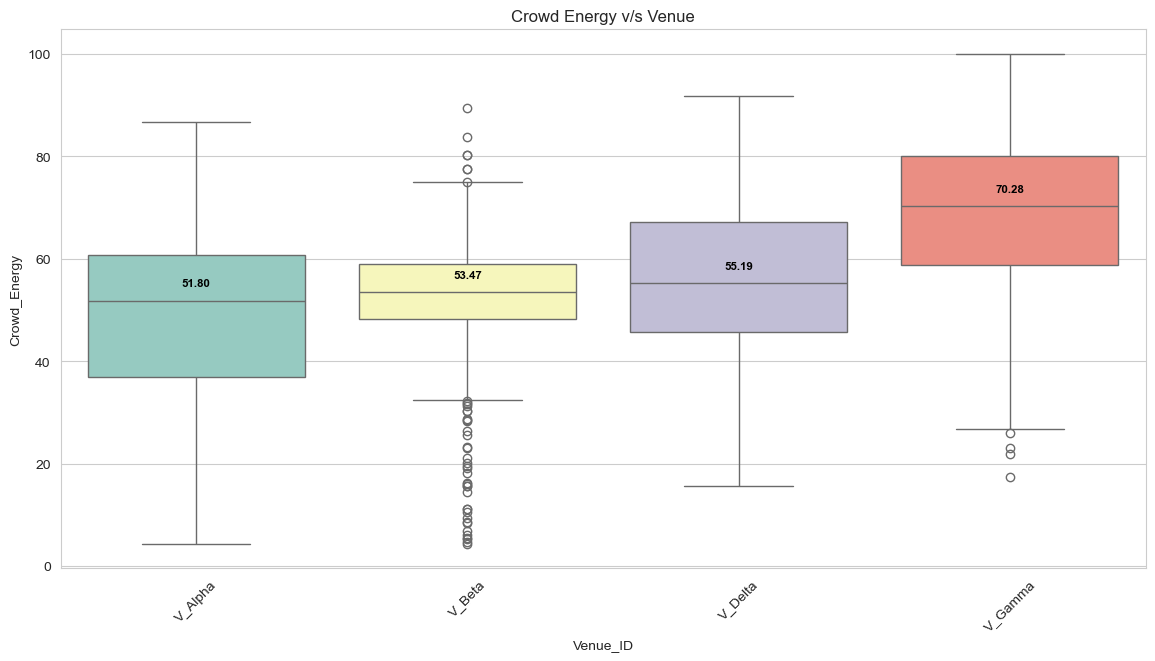

In [18]:

plt.figure(figsize=(14, 7))


ax = sns.boxplot(x='Venue_ID', y='Crowd_Energy', data=train, 
                 palette='Set3', hue='Venue_ID', legend=False)

medians = train.groupby(['Venue_ID'])['Crowd_Energy'].median()
vertical_offset = train['Crowd_Energy'].median() * 0.05 

for xtick in ax.get_xticks():
    venue_name = ax.get_xticklabels()[xtick].get_text()
    median_val = medians[venue_name]
    
    ax.text(xtick, 
            median_val + vertical_offset, 
            f'{median_val:.2f}', 
            horizontalalignment='center', 
            size='small', 
            color='black', 
            weight='semibold')

plt.title('Crowd Energy v/s Venue')
plt.xticks(rotation=45)
plt.show()

OBSERVATION:

Venues- V_Alpha, V_Beta, V_Delta have Crowd_Energy median between 51 and 56 but V_Gamma is the clear leader with a median of 70.28%. So, this venue is a major factor in predicting crowd energy.

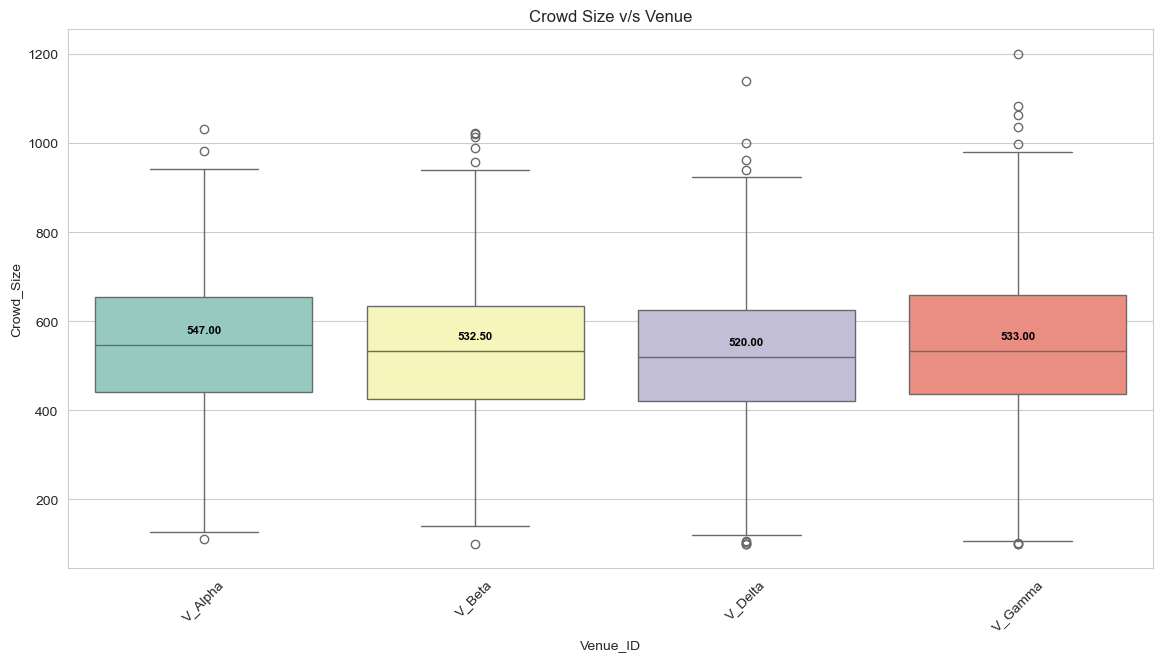

In [19]:
plt.figure(figsize=(14, 7))

ax = sns.boxplot(x='Venue_ID', y='Crowd_Size', data=train, 
                 palette='Set3', hue='Venue_ID', legend=False)

medians = train.groupby(['Venue_ID'])['Crowd_Size'].median()
vertical_offset = train['Crowd_Size'].median() * 0.05 

for xtick in ax.get_xticks():
    venue_name = ax.get_xticklabels()[xtick].get_text()
    median_val = medians[venue_name]
    
    ax.text(xtick, 
            median_val + vertical_offset, 
            f'{median_val:.2f}', 
            horizontalalignment='center', 
            size='small', 
            color='black', 
            weight='semibold')

plt.title('Crowd Size v/s Venue')
plt.xticks(rotation=45)
plt.show()

OBSERVATION:

Crowd_Size remains quite consistent across all venues (520 to 547).

So, Venue ID has quite influence on Crowd_Energy, but it has very little on the Crowd_Size.

LET SEE OTHER ANALYSIS IN FORM OF VERFYING THE VARIOUS HYPOTHESIS MADE IN THE SCRIBBLE. 

HYPOTHESIS: TUESDAY ARE CURSED   
(note tuesday is encoded as number '1' in this task, Monday is 0, all the way upto Sunday which is 6) 

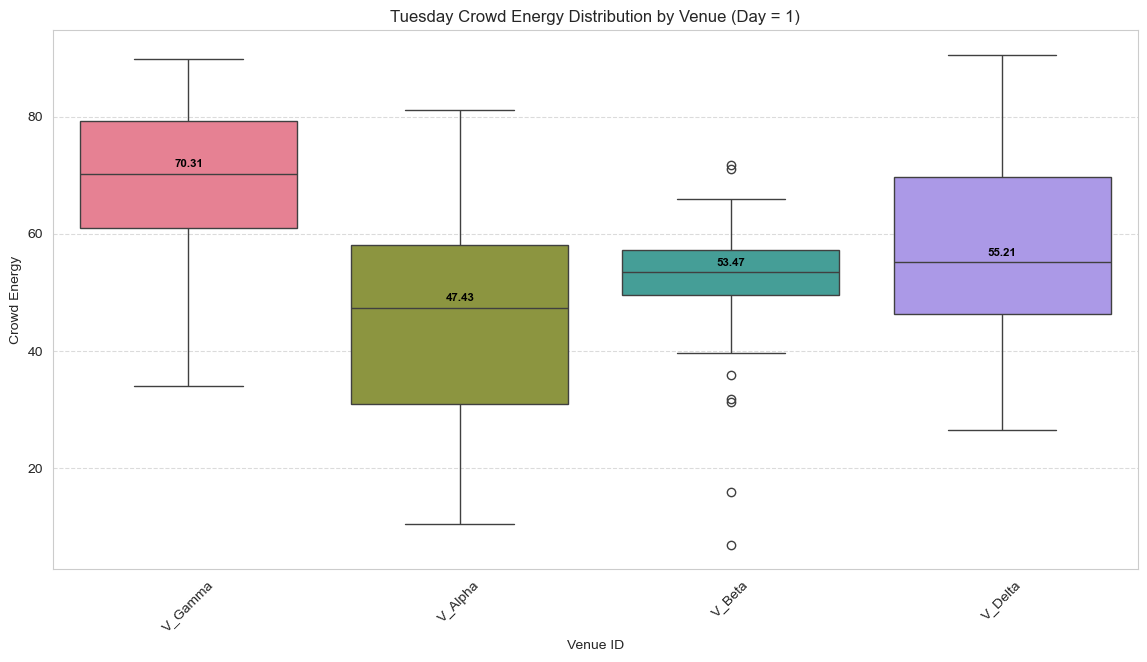

In [20]:

# Filter the data for Tuesday only
tuesday_data = train[train['Day_of_Week'] == 1].copy()

# Set the figure size
plt.figure(figsize=(14, 7))

ax = sns.boxplot(
    x='Venue_ID', 
    y='Crowd_Energy', 
    data=tuesday_data, 
    palette='husl', 
    hue='Venue_ID', 
    legend=False
)

# Calculate medians for Tuesday only
tuesday_medians = tuesday_data.groupby(['Venue_ID'])['Crowd_Energy'].median()

# Add the median text labels on the graph
# We use a small offset so the text sits just above the black line
vertical_offset = tuesday_data['Crowd_Energy'].median() * 0.02 

for xtick in ax.get_xticks():
    venue_name = ax.get_xticklabels()[xtick].get_text()
    
    # Check if we have data for this venue on Tuesday to avoid errors
    if venue_name in tuesday_medians:
        median_val = tuesday_medians[venue_name]
        ax.text(
            xtick, 
            median_val + vertical_offset, 
            f'{median_val:.2f}', 
            horizontalalignment='center', 
            size='small', 
            color='black', 
            weight='semibold'
        )

# Formatting
plt.title('Tuesday Crowd Energy Distribution by Venue (Day = 1)')
plt.xlabel('Venue ID')
plt.ylabel('Crowd Energy')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

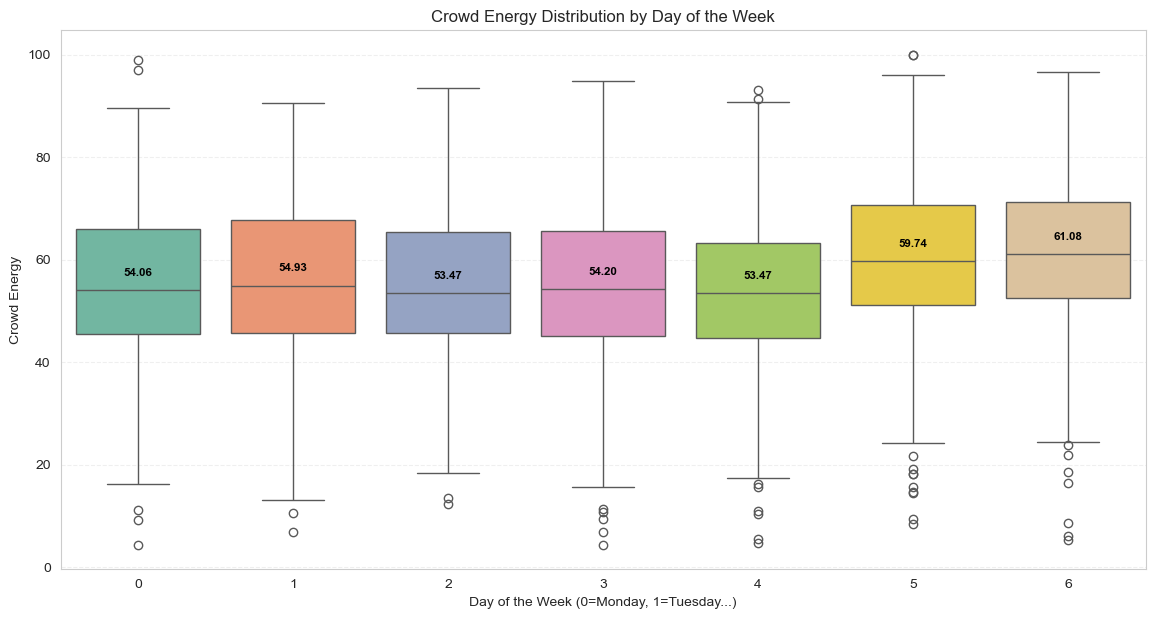

In [21]:

# Set the figure size
plt.figure(figsize=(14, 7))

# Create the boxplot (using hue and legend=False to stay future-proof)
ax = sns.boxplot(x='Day_of_Week', y='Crowd_Energy', data=train, 
                 palette='Set2', hue='Day_of_Week', legend=False)

# Calculate medians for each day
medians = train.groupby(['Day_of_Week'])['Crowd_Energy'].median()

# Set a small vertical offset for the text
# We calculate it based on the global median so it scales nicely
vertical_offset = train['Crowd_Energy'].median() * 0.05 

# Loop through each day (tick) and add the median text
for xtick in ax.get_xticks():
    # Get the day label (e.g., '0', '1', etc.)
    day_label = ax.get_xticklabels()[xtick].get_text()
    
    # Check if the day exists in our data and get its median
    if day_label in medians.index.astype(str):
        median_val = medians.loc[int(day_label)]
        
        ax.text(xtick, 
                median_val + vertical_offset, 
                f'{median_val:.2f}', 
                horizontalalignment='center', 
                size='small', 
                color='black', 
                weight='semibold')

# Formatting the plot
plt.title('Crowd Energy Distribution by Day of the Week')
plt.xlabel('Day of the Week (0=Monday, 1=Tuesday...)')
plt.ylabel('Crowd Energy')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

OBSERVATION: 

On the basis of above graph we can say that Day_of_Week has weak correlation with Crowd_Energy.

So, the hypothesis that Tuesday are cursed is not supported by data, even we can say that on tuesdays venue V_Gamma performs quite well.

HYPOTHESIS: LOW LEVEL OF VOLUME CAUSE LOW CROWD ENERGY LEVEL

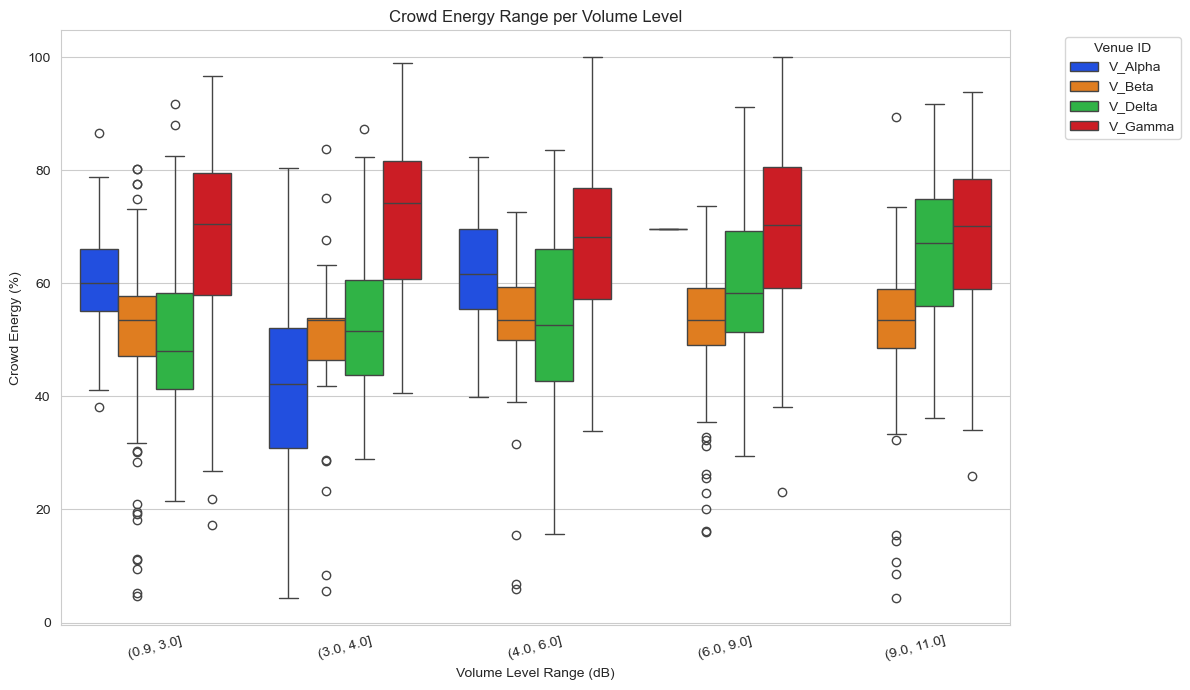

In [22]:

# Create a copy so 'train' remains unchanged
plot_df = train.copy()

# Add the temporary column to the COPY only
plot_df['Volume_Range'] = pd.qcut(plot_df['Volume_Level'], q=5, precision=1)

plt.figure(figsize=(12, 7))

# Use the copied dataframe (plot_df) for the boxplot
ax = sns.boxplot(data=plot_df, x='Volume_Range', y='Crowd_Energy', 
                 hue='Venue_ID', palette='bright')

plt.title('Crowd Energy Range per Volume Level')
plt.xlabel('Volume Level Range (dB)')
plt.ylabel('Crowd Energy (%)')
plt.xticks(rotation=15)

# Move legend outside to prevent it from covering data points
plt.legend(title='Venue ID', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


OBSERVATION: 

From the above plot we can see that there is quite weak correlation between crowd energy and volume levels, across all venues.

So, we cannot se say there is a venue which likes high volume or there is a venue which likes low volume.

But, we can say that concerts at venue V_Alpha genrally have low volume level.

So, the hypothysis that low volume levels cause low crowd energy is not supported by the data.

HYPOTHESIS: LARGE CROWD SIZE LEADS TO HIGH CROWD_ENERGY

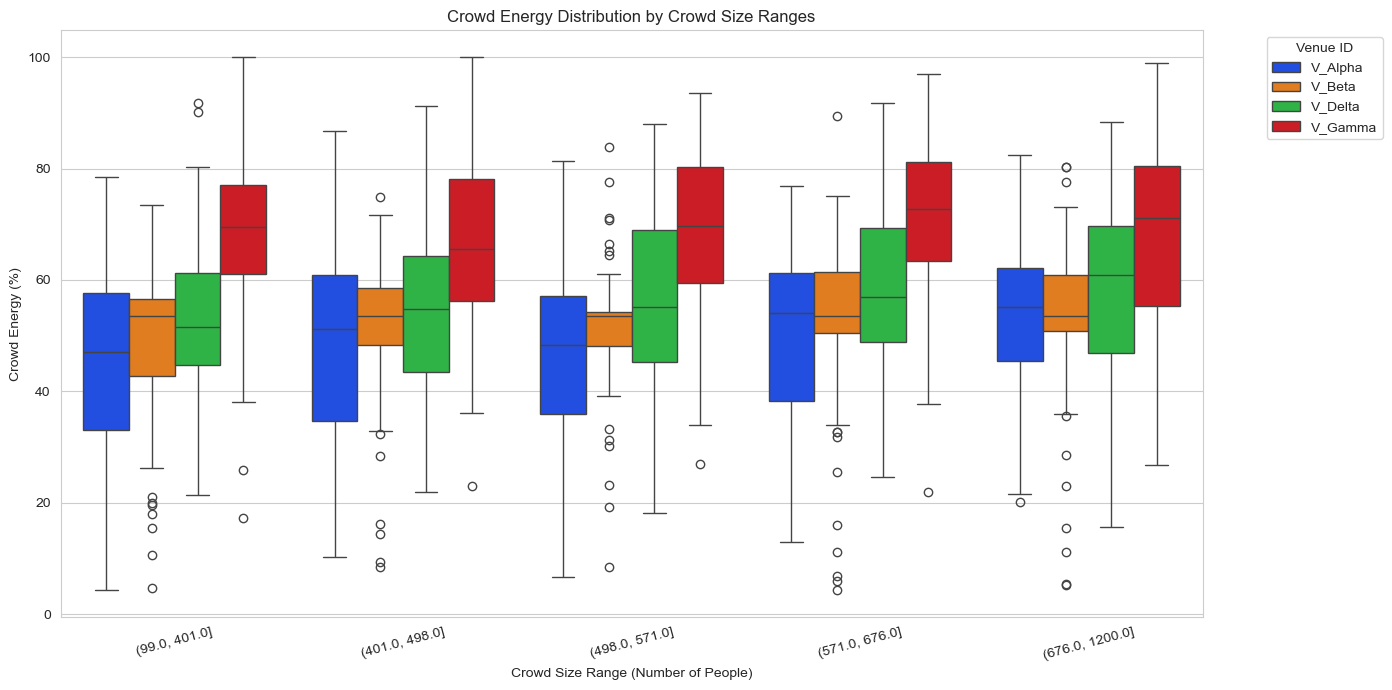

In [23]:

# Create a copy so 'train' remains unchanged
plot_df = train.copy()

# Add the temporary column for Crowd_Size ranges to the COPY
# This splits the crowd size into 5 equal-sized buckets
plot_df['Size_Range'] = pd.qcut(plot_df['Crowd_Size'], q=5, precision=0)

plt.figure(figsize=(14, 7))

# Use the copied dataframe for the boxplot
# x is the binned size, y is the energy, hue is the venue
ax = sns.boxplot(data=plot_df, x='Size_Range', y='Crowd_Energy', 
                 hue='Venue_ID', palette='bright')

# Formatting
plt.title('Crowd Energy Distribution by Crowd Size Ranges')
plt.xlabel('Crowd Size Range (Number of People)')
plt.ylabel('Crowd Energy (%)')
plt.xticks(rotation=15)

# Move legend outside
plt.legend(title='Venue ID', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

OBSERVATION: 

On the basis of above graph we can say that Crowd_Energy have quite weak correlation with Crowd_Size across all four venues.

So, the hypothesis is not supported by the data.

HYPOTHESIS: TIME AFFECTS THE CROWD ENERGY LEVELS

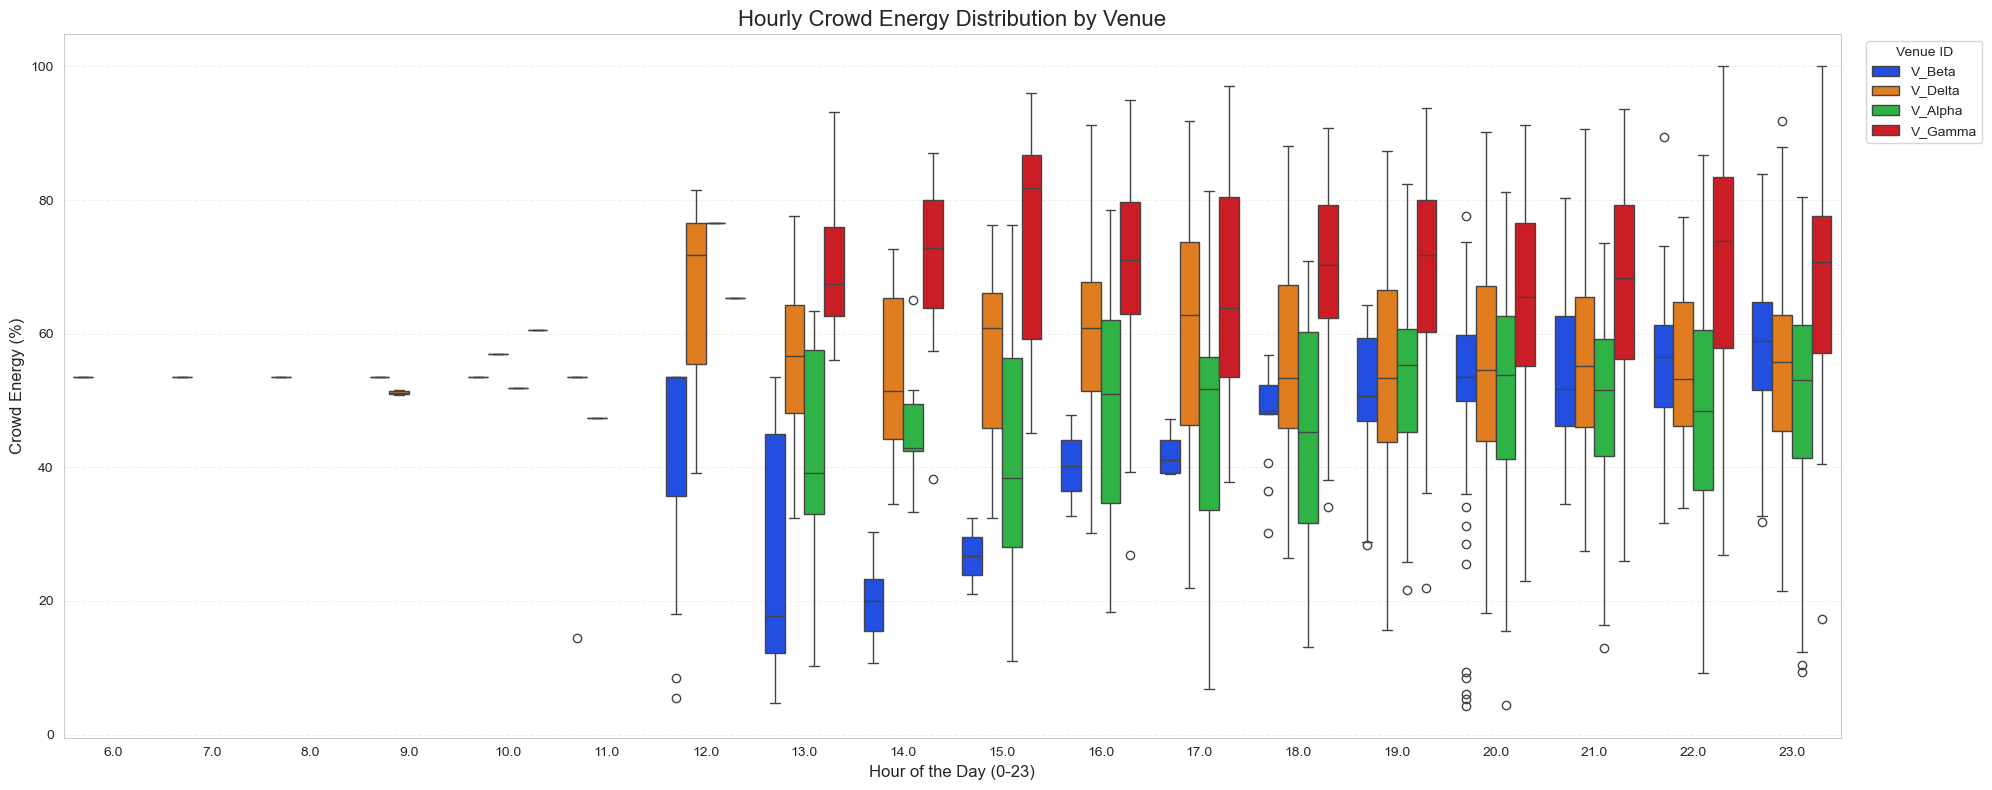

In [24]:

plt.figure(figsize=(20, 8))

ax = sns.boxplot(
    data=train, 
    x='Time', 
    y='Crowd_Energy', 
    hue='Venue_ID', 
    palette='bright'
)

plt.title('Hourly Crowd Energy Distribution by Venue', fontsize=16)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Crowd Energy (%)', fontsize=12)

plt.legend(title='Venue ID', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

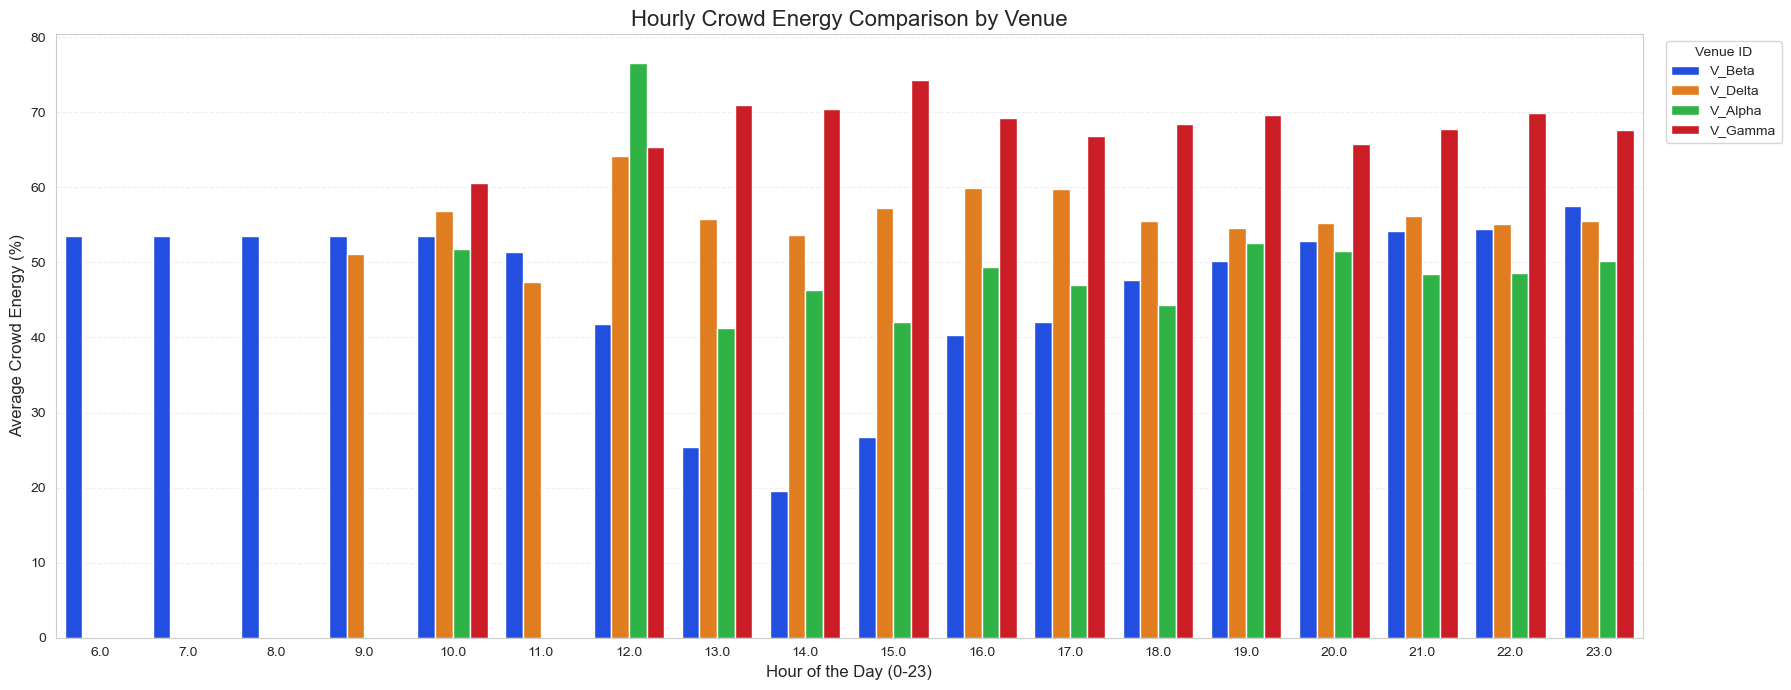

In [25]:

plt.figure(figsize=(18, 7))

ax = sns.barplot(
    data=train, 
    x='Time', 
    y='Crowd_Energy', 
    hue='Venue_ID', 
    palette='bright',
    errorbar=None
)

plt.title('Hourly Crowd Energy Comparison by Venue', fontsize=16)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Average Crowd Energy (%)', fontsize=12)

plt.legend(title='Venue ID', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

OBSERVATION: 

Venues V_Delta, V_Alpha and V_Gamma mainly have concerts after 10:00 till 23:00 whereas venue V_Beta has concerts from 6:00 till 23:00.

Hour of the day have little influence on crowd energy levels at venues V_Gamma, V_Alpha, V_Delta after 10:00, with a suprising peak of crowd energy level at 12:00 at venue V_Alpha.

Crowd energy levels at venue V_Beta almost remain constant from 6:00 to 11:00 then decreases till 14:00 and thereafter increases till 23:00.

So, we can say that the hypothesis is partially supported by the data.

HYPOTHESIS: PHASES OF MOON HAVE INFLUENCE ON CROWD ENERGY

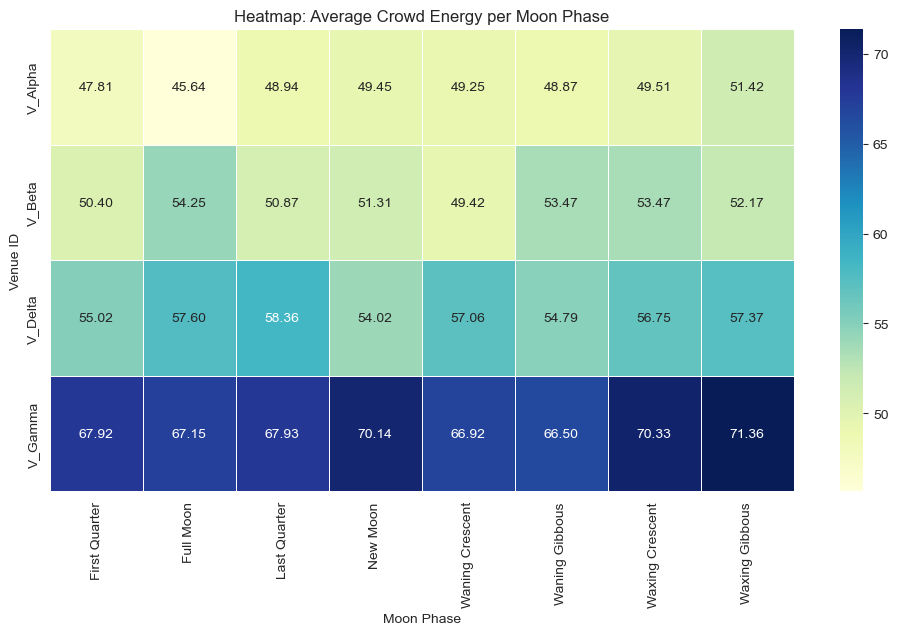

In [26]:

# Create a Table to see Average Energy for each Venue/Moon combination
table = train.pivot_table(
    values='Crowd_Energy', 
    index='Venue_ID', 
    columns='Moon_Phase', 
    aggfunc='mean'
)

# Plotting the Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(table, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)

plt.title('Heatmap: Average Crowd Energy per Moon Phase')
plt.xlabel('Moon Phase')
plt.ylabel('Venue ID')
plt.show()

OBSERVATION: 

Crowd_Energy has very weak correlation with Moon_Phase, we cannot say full moon has some special performance.

So, hypothesis that crowd energy depends on moon phase is not supported by the data.
(The Drummer is right here)

HYPOTHESIS: OUTFIT AFFECTS CROWD ENERGY LEVELS

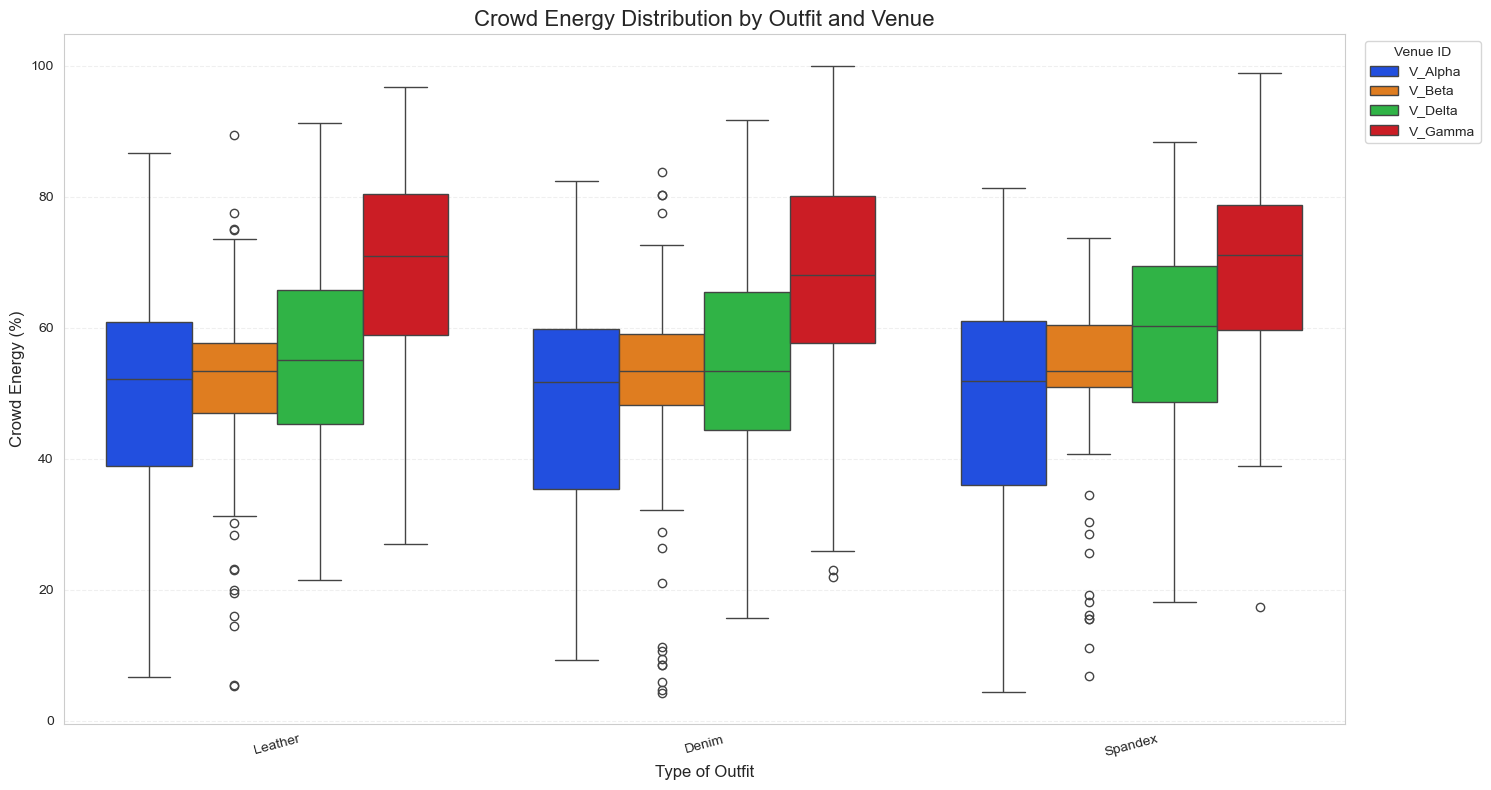

In [27]:

plt.figure(figsize=(15, 8))

ax = sns.boxplot(
    data=train, 
    x='Band_Outfit', 
    y='Crowd_Energy', 
    hue='Venue_ID', 
    palette='bright'
)

plt.title('Crowd Energy Distribution by Outfit and Venue', fontsize=16)
plt.xlabel('Type of Outfit', fontsize=12)
plt.ylabel('Crowd Energy (%)', fontsize=12)

plt.legend(title='Venue ID', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

OBSERVATION:

From the plot we can see that crowd energy levels at respective venues have very weak correlation with Band_outfit.

So, the hypothysis that band outfits affect crowd energy levels is not supported by data. 

(In the scribble it is just a misconception that spandex is always right and we don't know what does the red sock also do for crowd energy levels (as mentioned in the scribble).

HYPOTHESIS: OUTDOOR VENUES SUFFER IN STORMS

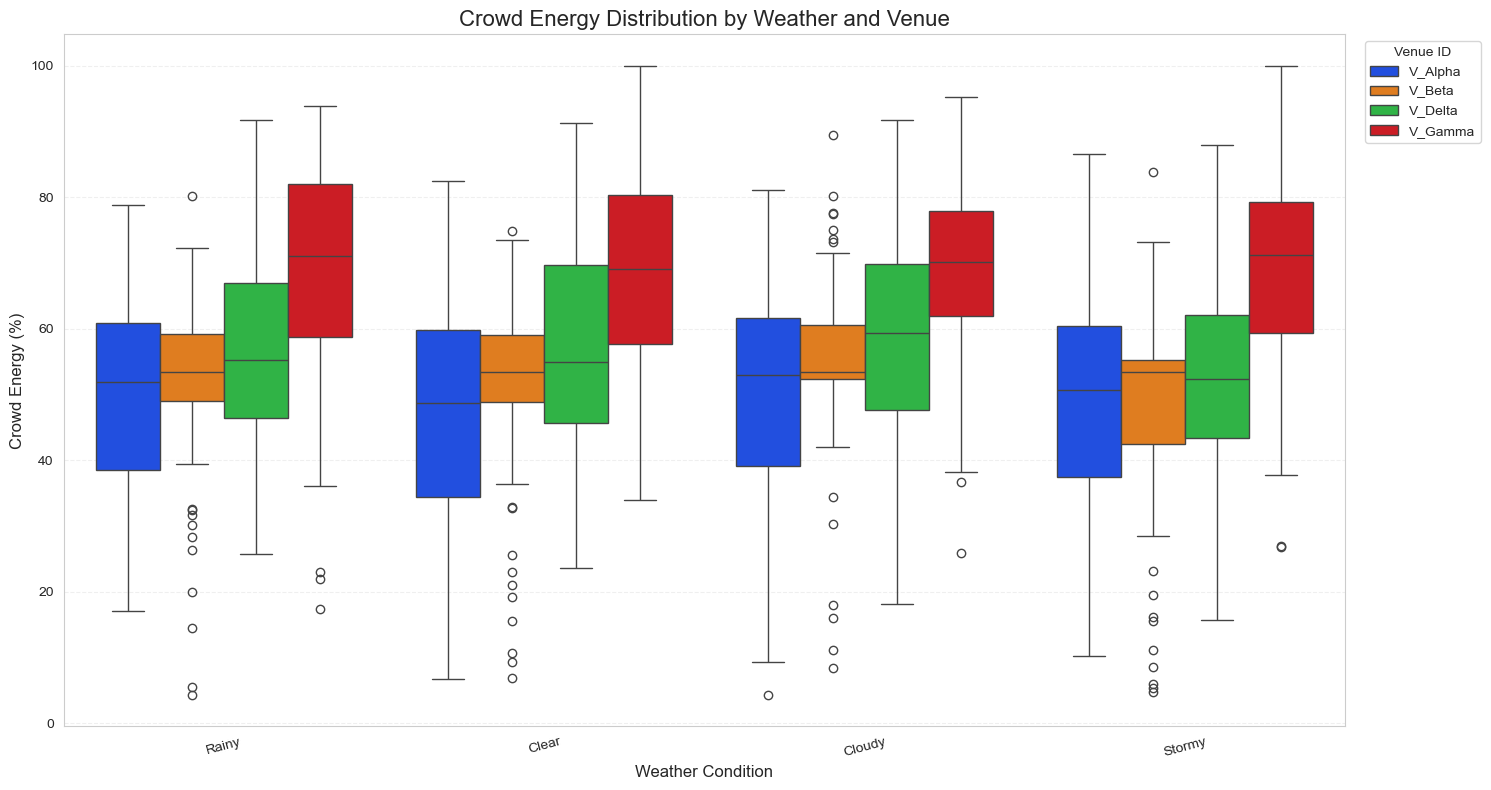

In [28]:

plt.figure(figsize=(15, 8))

ax = sns.boxplot(
    data=train, 
    x='Weather', 
    y='Crowd_Energy', 
    hue='Venue_ID', 
    palette='bright'
)

plt.title('Crowd Energy Distribution by Weather and Venue', fontsize=16)
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Crowd Energy (%)', fontsize=12)

plt.legend(title='Venue ID', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [29]:

weather_table = train.groupby('Weather')['Crowd_Energy'].median().sort_values(ascending=False).reset_index()

# Rename columns for clarity
weather_table.columns = ['Weather Condition', 'Median Energy (%)']

print(weather_table)

  Weather Condition  Median Energy (%)
0            Cloudy              57.94
1             Clear              56.04
2             Rainy              55.26
3            Stormy              53.47


OBSERVATION: 

Here also we can see that crowd energy level has weak correlation with the weather either we talk venue wise or overall.

So, hypothesis that storm affects outdoor venue is not supported since we have no evidence of storm affecting any venue biasly.

Also we can say that across all weathers crowd energy levels on an average are in order V_Gamma > V_Delta > V_Beta > V_Alpha but it is striclty NOT an indication of performing better in a certain weather by a certain venue, its just a simple fact.

HYPOTHESIS: VENUES ARE PRICE SENSITIVE, MAY BE A PARTICULAR

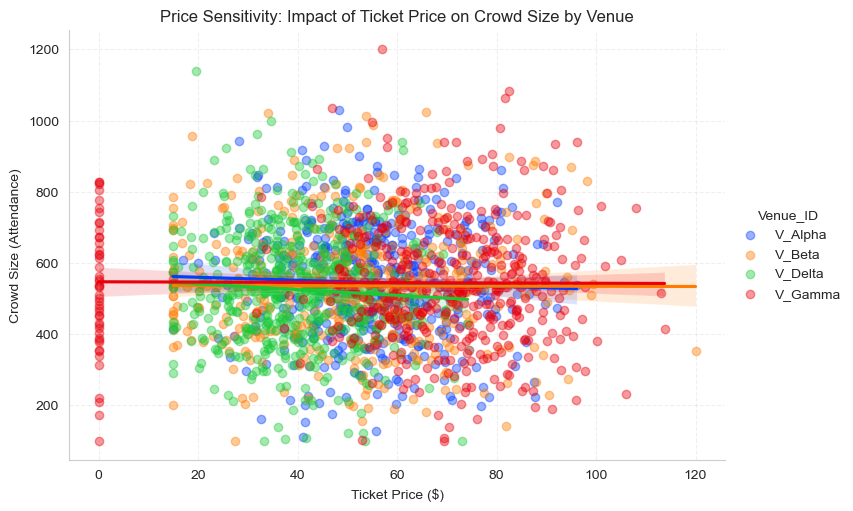

In [30]:

sns.lmplot(
    data=train, 
    x='Ticket_Price', 
    y='Crowd_Size', 
    hue='Venue_ID', 
    palette='bright',
    aspect=1.5,      
    scatter_kws={'alpha':0.4} # Makes dots slightly transparent to see overlaps
)

plt.title('Price Sensitivity: Impact of Ticket Price on Crowd Size by Venue')
plt.xlabel('Ticket Price ($)')
plt.ylabel('Crowd Size (Attendance)')

plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

OBSERVATION: 

From the plot above we can say that venues V_Alpha, V_Beta, V_Gamma are quite less price sensitive whereas venue V_Delta is slightly price sensitive (for having high price sensitivity the slope of line should be more).

So, the hypothysis is partially supported for venue V_Delta (The mosh pit).

HYPOTHESIS: IS $62 A SWEET SPOT AS MENTIONED IN THE SCRIBBLE?

Here we will be judging it on the basis of a success_score which is defined as: 

Success_Score = Revenue * Crowd_Energy/100,  Revenue = Ticket_Price * Crowd_Size  (to include the weightage of energy levels also)

DOING SOME INTERACTION BETWEEN COLUMNS TO DERIVE SOME MEANINGFUL IN CONTEXT OF ABOVE HYPOTHESIS

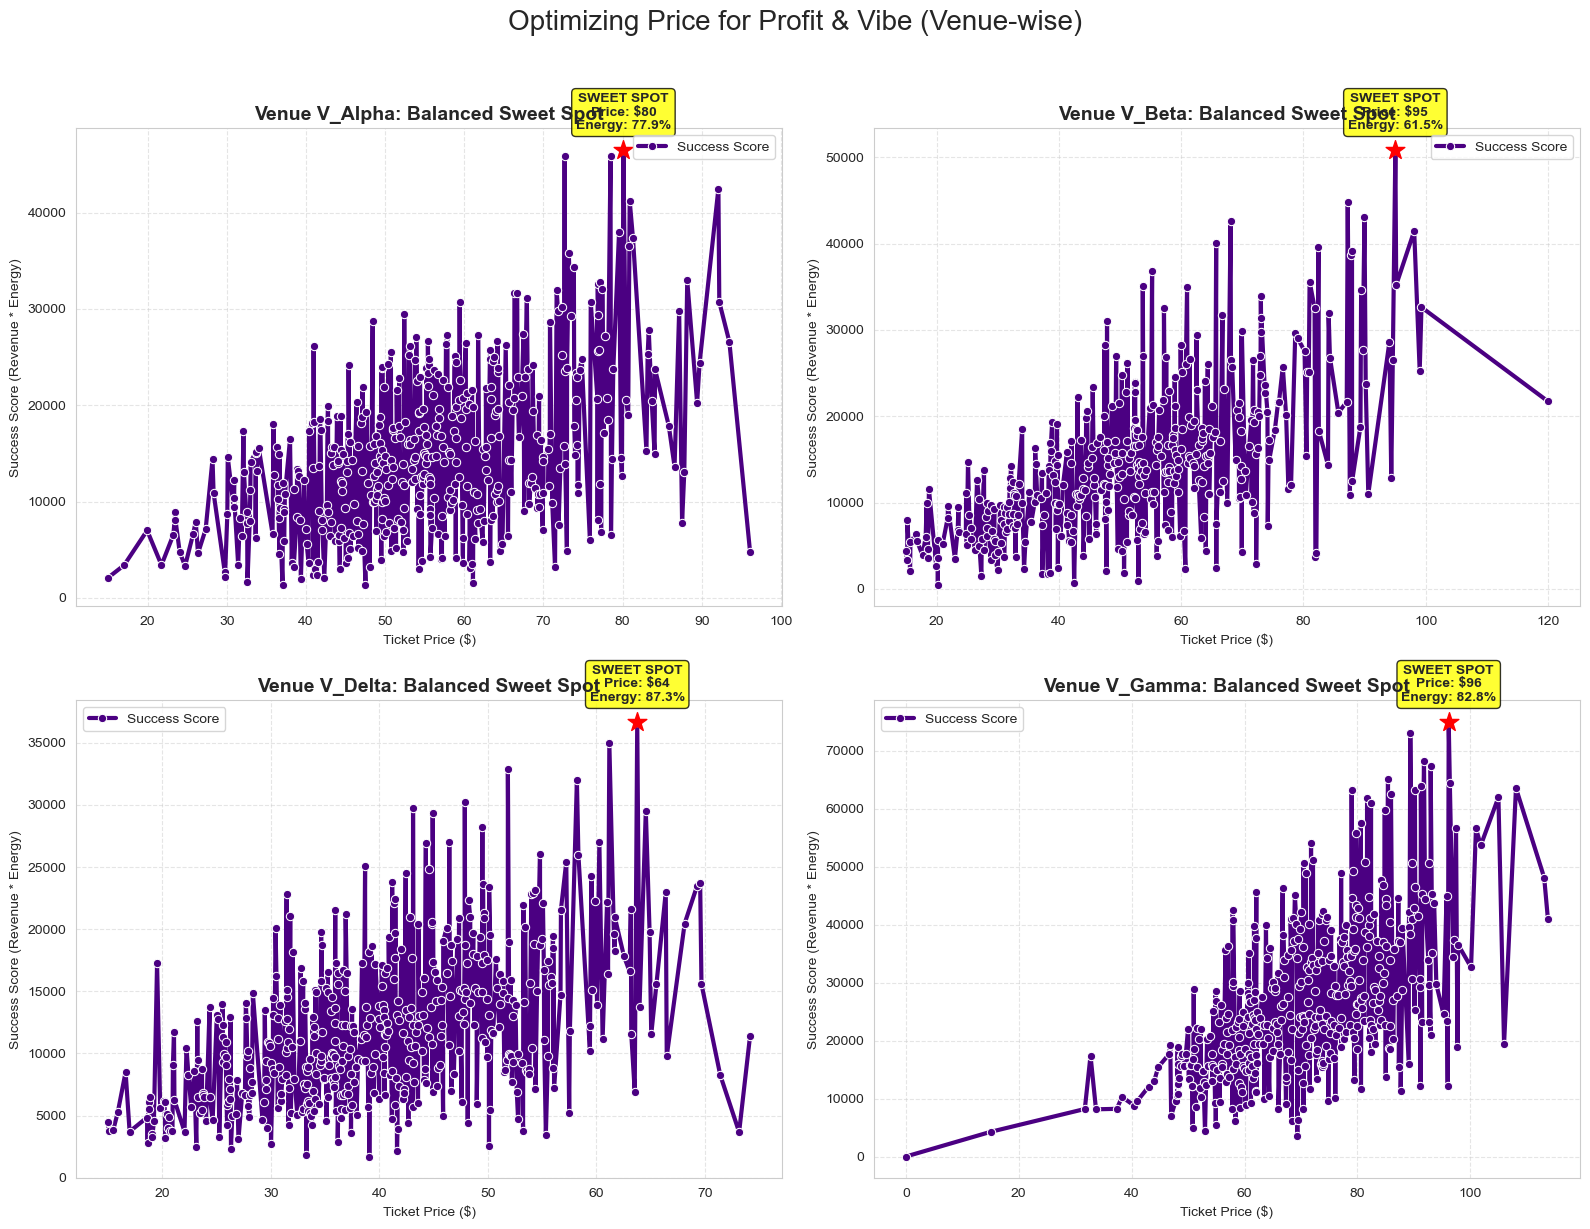

In [31]:

# Prepare data in a temp dataframe
plot_df = train.copy()
plot_df['Revenue'] = plot_df['Ticket_Price'] * plot_df['Crowd_Size']

plot_df['Success_Score'] = plot_df['Revenue'] * (plot_df['Crowd_Energy'] / 100)

# Average the results per price point
summary = plot_df.groupby(['Venue_ID', 'Ticket_Price'])[['Success_Score', 'Crowd_Energy']].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
venues = sorted(summary['Venue_ID'].unique())

for i, venue in enumerate(venues):
    ax = axes[i]
    v_data = summary[summary['Venue_ID'] == venue]
    
    # Plot the Success Score Curve
    sns.lineplot(data=v_data, x='Ticket_Price', y='Success_Score', 
                 ax=ax, marker='o', linewidth=3, color='indigo', label='Success Score')
    
    # Find the peak (The Sweet Spot)
    peak = v_data.loc[v_data['Success_Score'].idxmax()]
    
    # Mark the Sweet Spot
    ax.scatter(peak['Ticket_Price'], peak['Success_Score'], color='red', s=200, zorder=5, marker='*')
    
    # Add a clean label for the sweet spot
    ax.annotate(f"SWEET SPOT\nPrice: ${peak['Ticket_Price']:.0f}\nEnergy: {peak['Crowd_Energy']:.1f}%",
                 xy=(peak['Ticket_Price'], peak['Success_Score']),
                 xytext=(0, 15), textcoords='offset points',
                 ha='center', fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", alpha=0.8))

    ax.set_title(f'Venue {venue}: Balanced Sweet Spot', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ticket Price ($)')
    ax.set_ylabel('Success Score (Revenue * Energy)')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Optimizing Price for Profit & Vibe (Venue-wise)', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

OBSERVATION: 

On the basis of above graphs we can say that hypothysis is supported since mathematically (according to our definition) the sweet spot came out to be 64 dollars for the venue V_Delta (the mosh pit).

HYPOTHESIS: OPENER RATING AFFECTS CROWD ENERGY

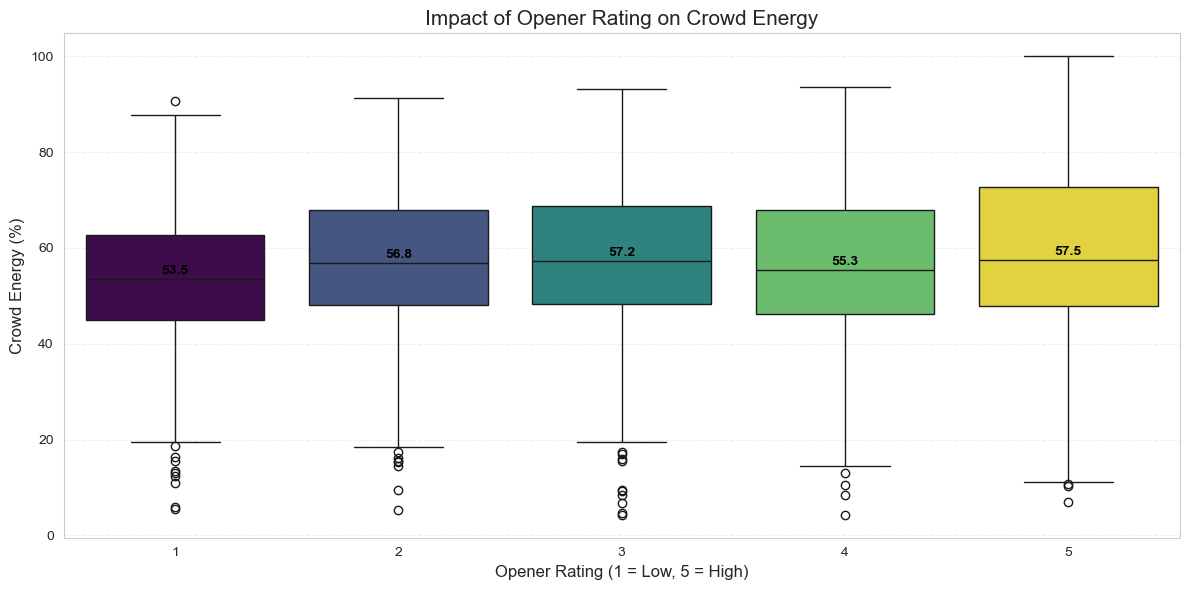

In [32]:

plt.figure(figsize=(12, 6))

ax = sns.boxplot(data=train, x='Opener_Rating', y='Crowd_Energy', 
                 palette='viridis', hue='Opener_Rating', legend=False)

medians = train.groupby(['Opener_Rating'])['Crowd_Energy'].median()

vertical_offset = train['Crowd_Energy'].median() * 0.02 

for xtick in ax.get_xticks():
    
    rating_label = int(ax.get_xticklabels()[xtick].get_text())
    
    if rating_label in medians.index:
        median_val = medians.loc[rating_label]
        
        ax.text(xtick, 
                median_val + vertical_offset, 
                f'{median_val:.1f}', 
                horizontalalignment='center', 
                size='medium', 
                color='black', 
                weight='bold')

plt.title('Impact of Opener Rating on Crowd Energy', fontsize=15)
plt.xlabel('Opener Rating (1 = Low, 5 = High)', fontsize=12)
plt.ylabel('Crowd Energy (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

OBSERVATION: 

Opener rating also has quite weak correlation with crowd energy,

So, hypothysis that crowd energy is affected by opener rating is almost not supported by our data.

HYPOTHESIS: CROWD SIZE AND CROWD ENERGY ARE RELATED TO EACH OTHER

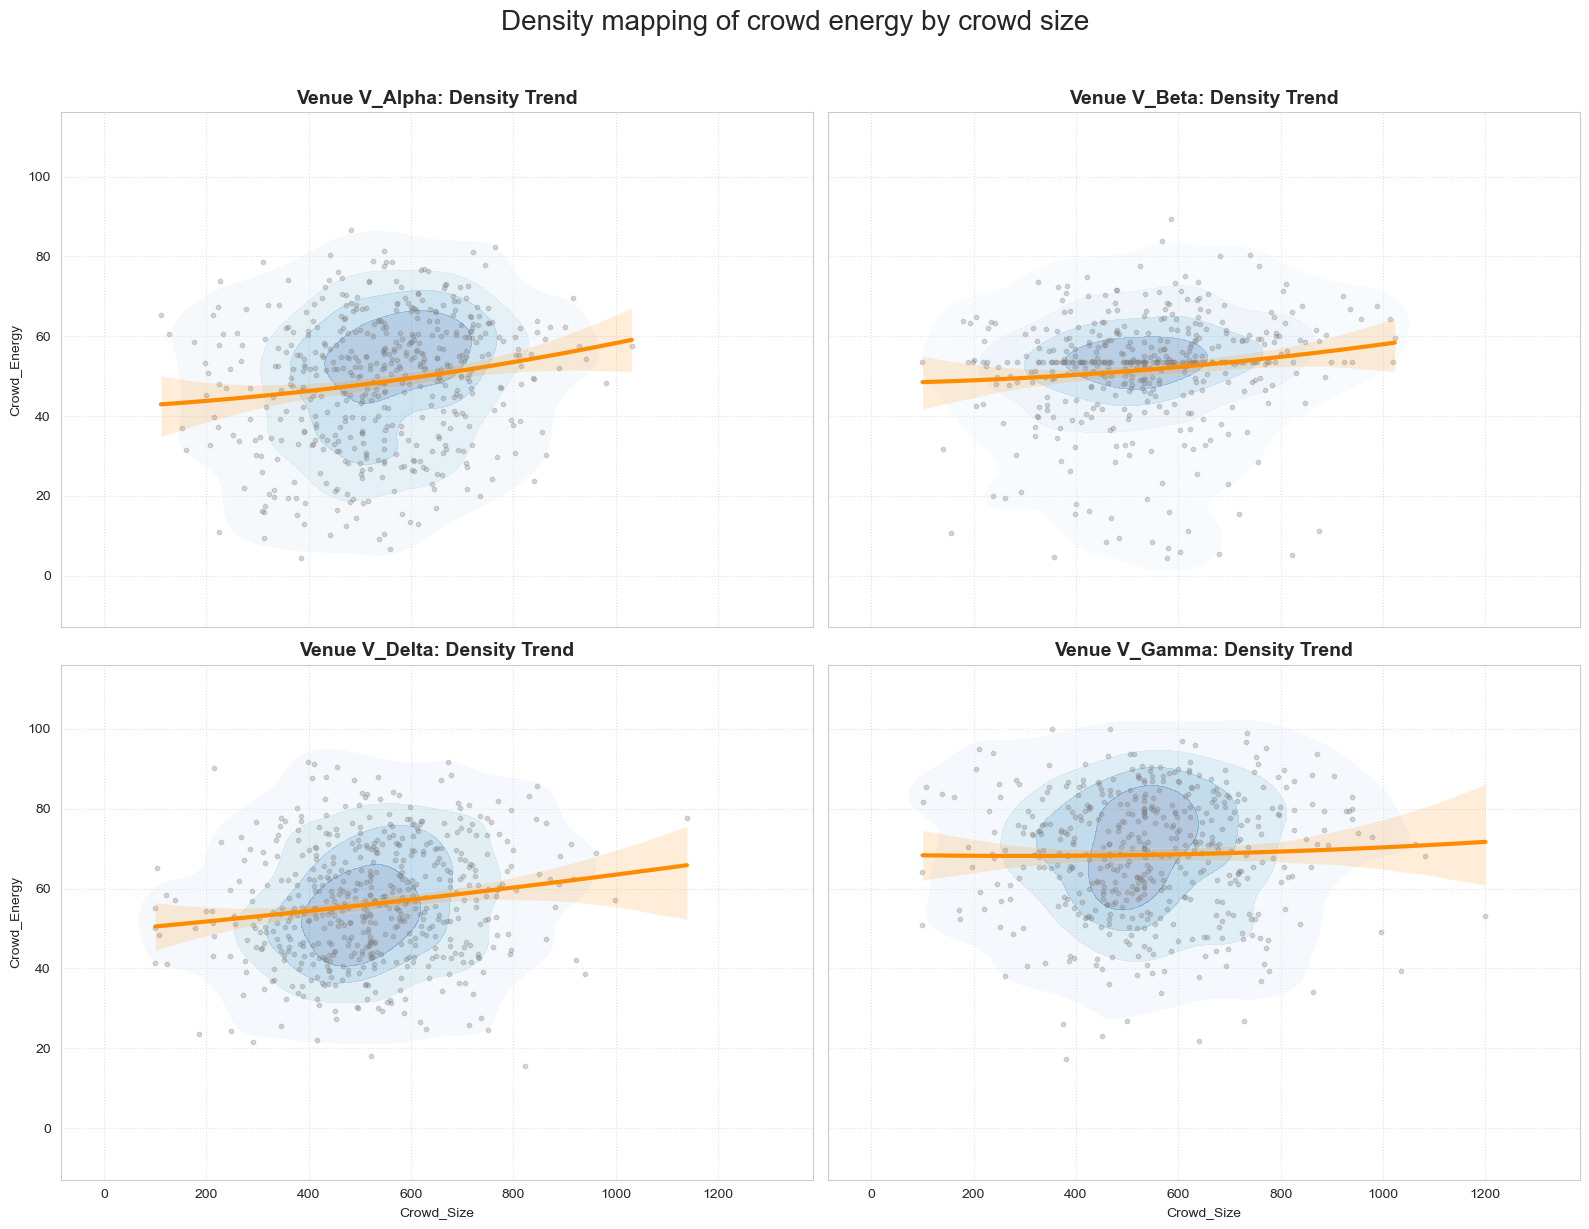

In [33]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()
venues = sorted(train['Venue_ID'].unique())

for i, venue in enumerate(venues):
    ax = axes[i]
    venue_data = train[train['Venue_ID'] == venue]
    
    # a density plot
    sns.kdeplot(
        data=venue_data, x='Crowd_Size', y='Crowd_Energy', 
        ax=ax, fill=True, thresh=0.05, levels=5, cmap="Blues", alpha=0.3
    )
    
    # a Polynomial Fit, beacause relation is non-linaer
    sns.regplot(
        data=venue_data, x='Crowd_Size', y='Crowd_Energy', 
        ax=ax, scatter=True, order=2, 
        scatter_kws={'s': 10, 'alpha': 0.3, 'color': 'gray'},
        line_kws={'color': 'darkorange', 'lw': 3}
    )
    
    ax.set_title(f'Venue {venue}: Density Trend', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Density mapping of crowd energy by crowd size', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

OBSERVATION: 

From the above plots we can see that the relationship between crowd size and crowd energy is non linear, amd there is no as such strong correlation between crowd energy and crowd size.

HYPOTHESIS: WEEKENDS ARE BETTER

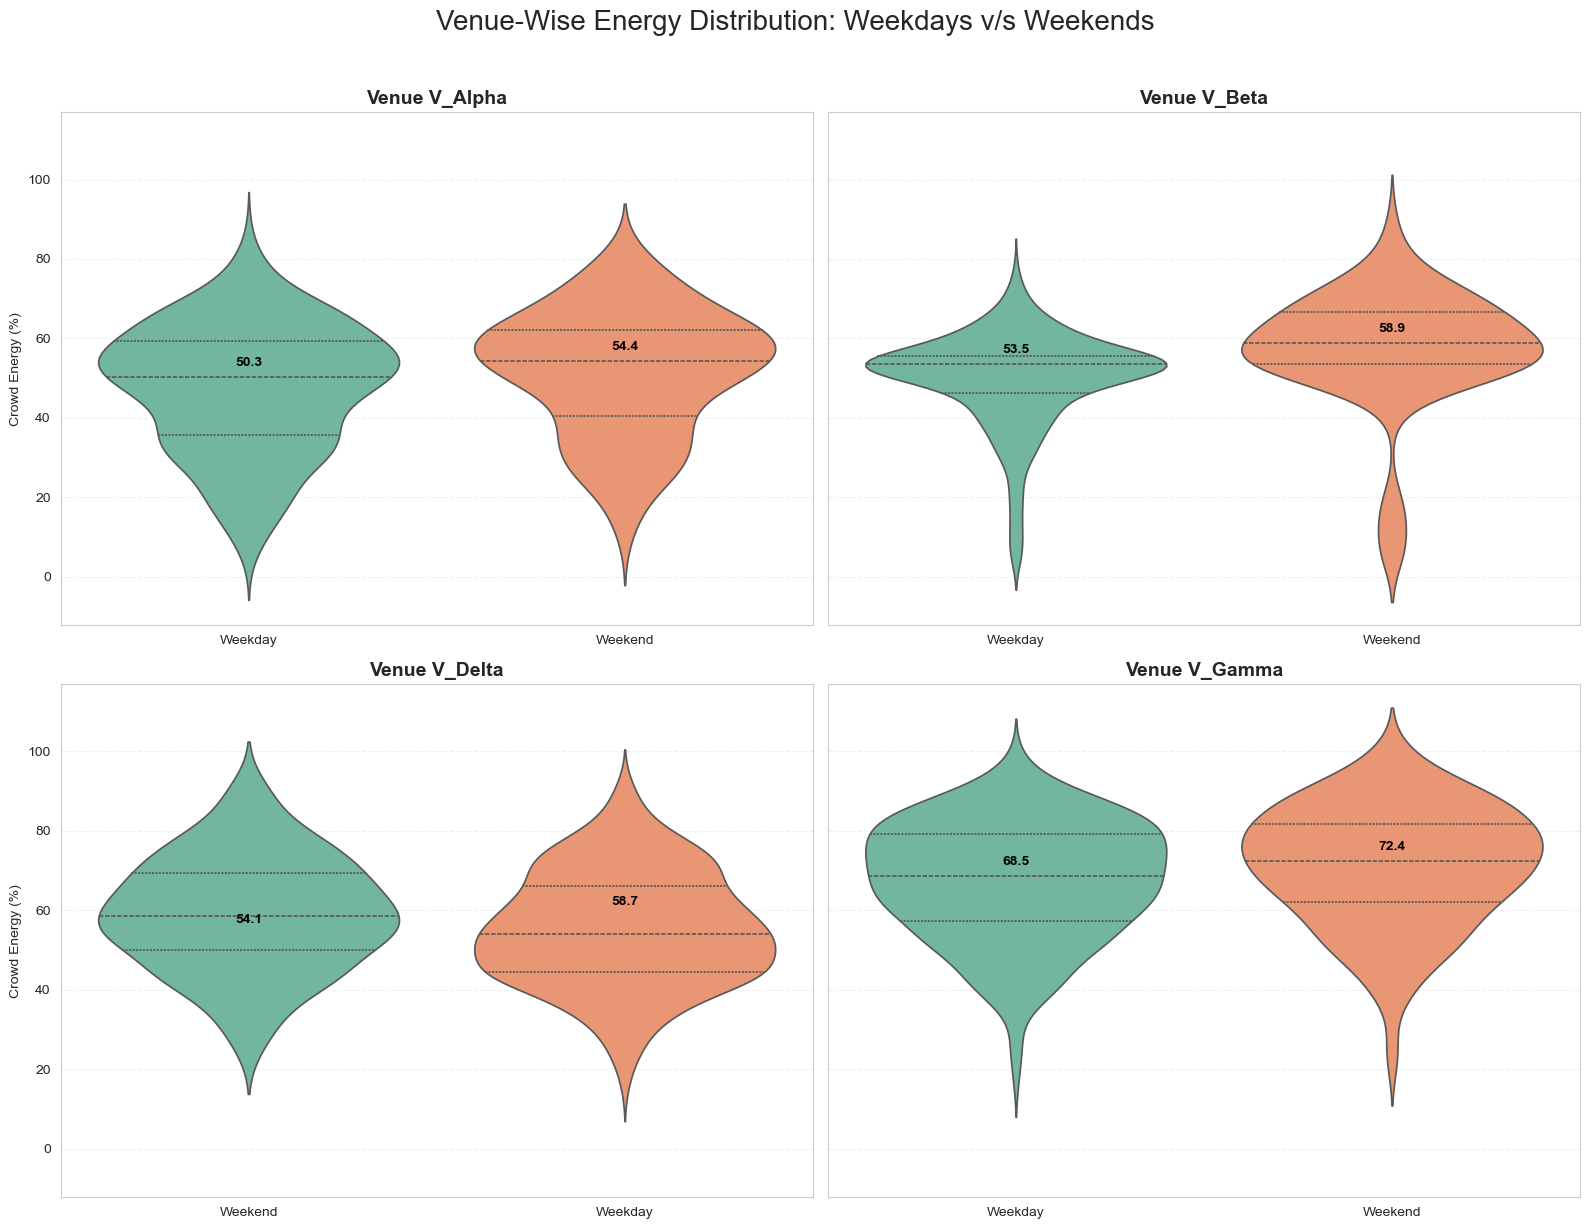

In [34]:

temp_df = train.copy()
temp_df['Day_Type'] = temp_df['Day_of_Week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

venues = sorted(temp_df['Venue_ID'].unique())

for i, venue in enumerate(venues):
    ax = axes[i]
    venue_data = temp_df[temp_df['Venue_ID'] == venue]
    
    # Create the violin plot
    sns.violinplot(
        data=venue_data, 
        x='Day_Type', 
        y='Crowd_Energy', 
        ax=ax, 
        palette='Set2', 
        inner='quartile',
        hue='Day_Type',
        legend=False
    )
    
    medians = venue_data.groupby('Day_Type')['Crowd_Energy'].median()
    for j, label in enumerate(['Weekday', 'Weekend']):
        if label in medians:
            m_val = medians[label]
            ax.text(j, m_val + 2, f'{m_val:.1f}', 
                    ha='center', va='bottom', fontweight='bold', color='black')
    
    ax.set_title(f'Venue {venue}', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Crowd Energy (%)')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle('Venue-Wise Energy Distribution: Weekdays v/s Weekends', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

OBSERVATION: 

From the above plots we can see that weekends are always better than weekdays but approximately only 4% (difference in crowd energy level)

So, hypothesis that weekends are better than weekdays is supported by our data but the margin is narrow.

HYPOTHESIS: CROWD ENERGY AFFECTS MERCHANDISE SALES

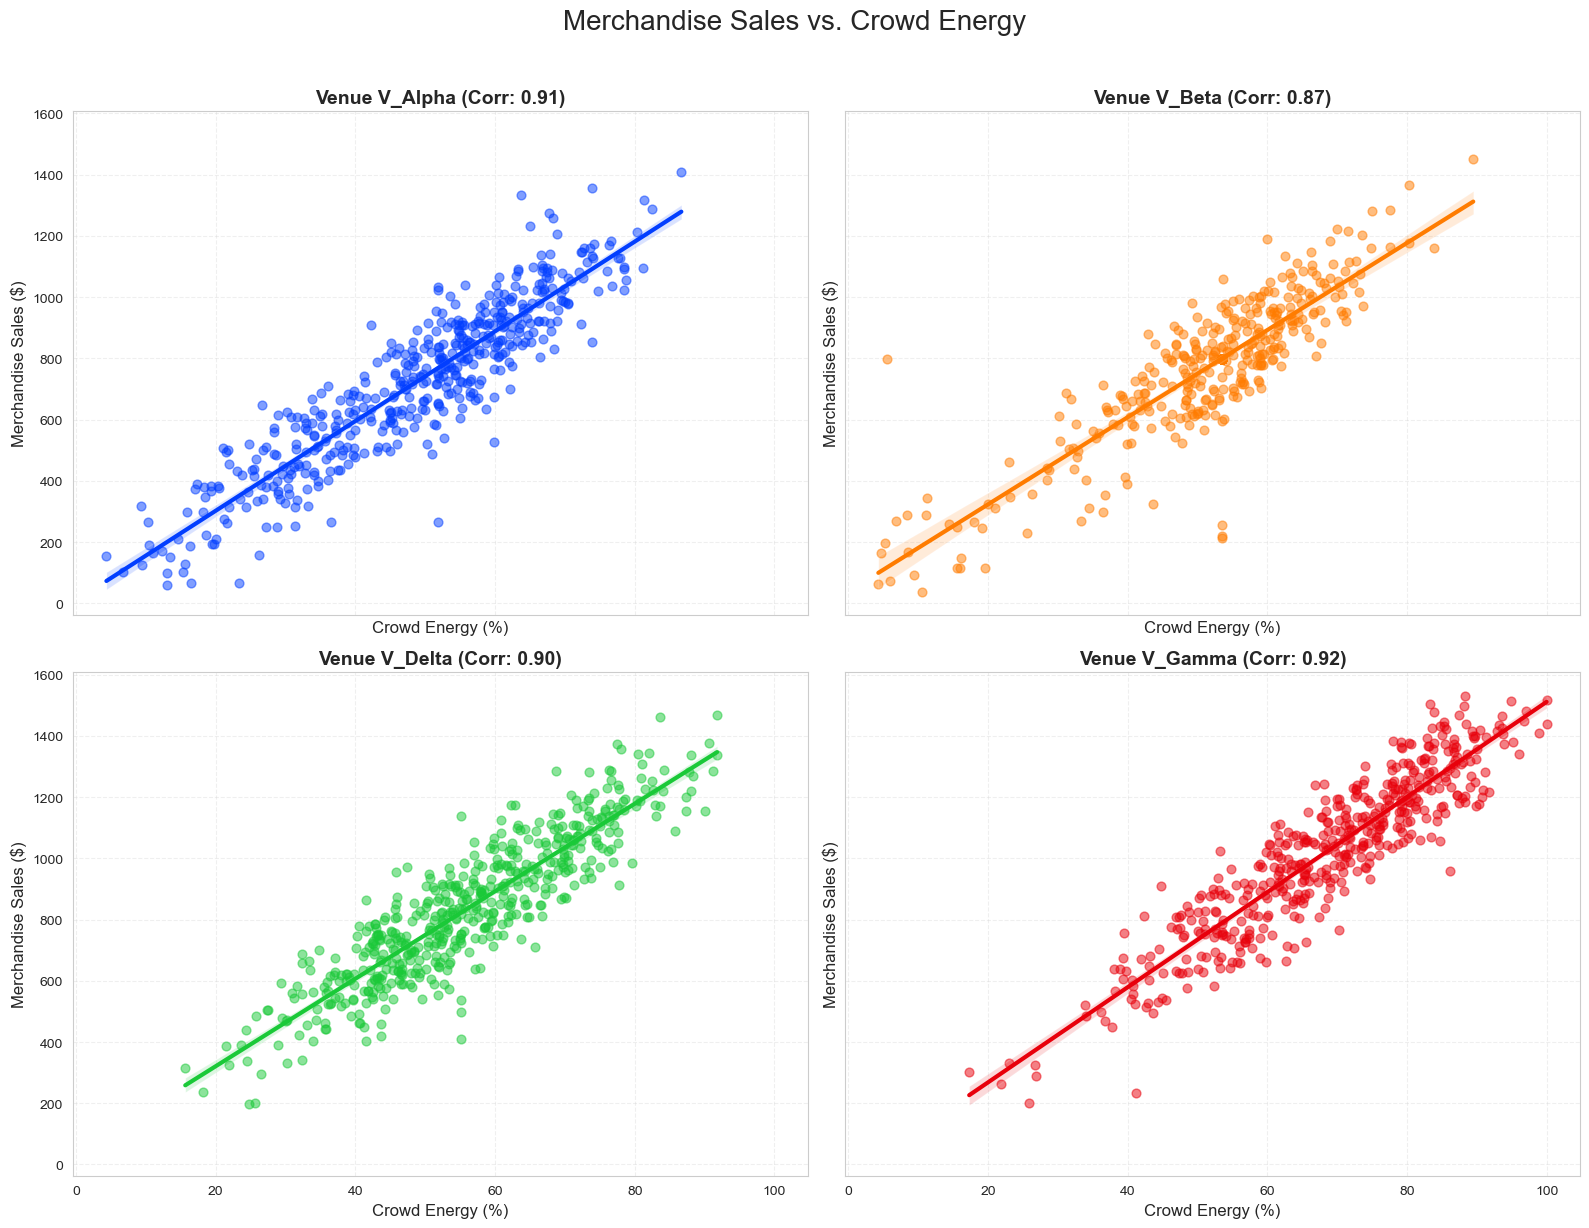

In [35]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

venues = sorted(train['Venue_ID'].unique())
colors = sns.color_palette('bright', n_colors=len(venues))

for i, venue in enumerate(venues):
    ax = axes[i]
    venue_data = train[train['Venue_ID'] == venue]
    
    # Create the regression plot
    sns.regplot(
        data=venue_data,
        x='Crowd_Energy',
        y='Merch_Sales_Post_Show',
        ax=ax,
        scatter_kws={'alpha': 0.5, 'color': colors[i], 's': 40},
        line_kws={'color': colors[i], 'lw': 3}
    )
    
    # Calculate correlation
    correlation = venue_data['Crowd_Energy'].corr(venue_data['Merch_Sales_Post_Show'])
    
    ax.set_title(f'Venue {venue} (Corr: {correlation:.2f})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Crowd Energy (%)', fontsize=12)
    ax.set_ylabel('Merchandise Sales ($)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Merchandise Sales vs. Crowd Energy', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

OBSERVATION: 

We can cleary see that at all four venues, there is very strong correlation between crowd energy and the merchandise sale.

So, hypothesis that crowd energy affects the merchandise sales is strongly supported by the data.

HYPOTHESIS: WHICH MATTER MORE CROWD SIZE OR VOLUME LEVEL? (but do they affect in first place)

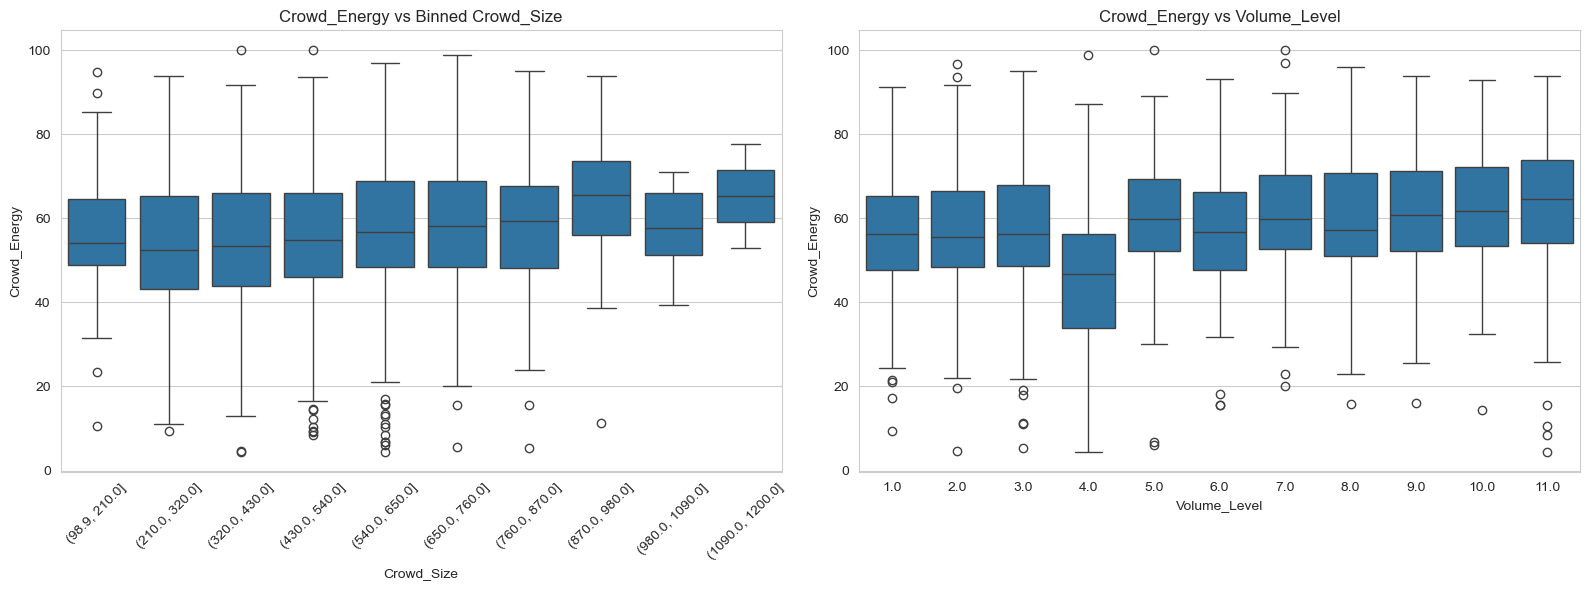

In [36]:

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# using intervals this time

sns.boxplot(
    x=pd.cut(train['Crowd_Size'], bins=10), 
    y=train['Crowd_Energy'],
    ax=axes[0]
)
axes[0].set_title('Crowd_Energy vs Binned Crowd_Size')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(
    x=train['Volume_Level'],
    y=train['Crowd_Energy'],
    ax=axes[1]
)
axes[1].set_title('Crowd_Energy vs Volume_Level')

plt.tight_layout()
plt.show()


OBSERVATION: 

From the above plots we can say that both crowd size and volume level have very wek correlation with crowd energy so it is bogus to talk about which matters more.

HYPOTHESIS: CROWD ENERGY DROPS AFTER CERTAIN TICKET PRICE

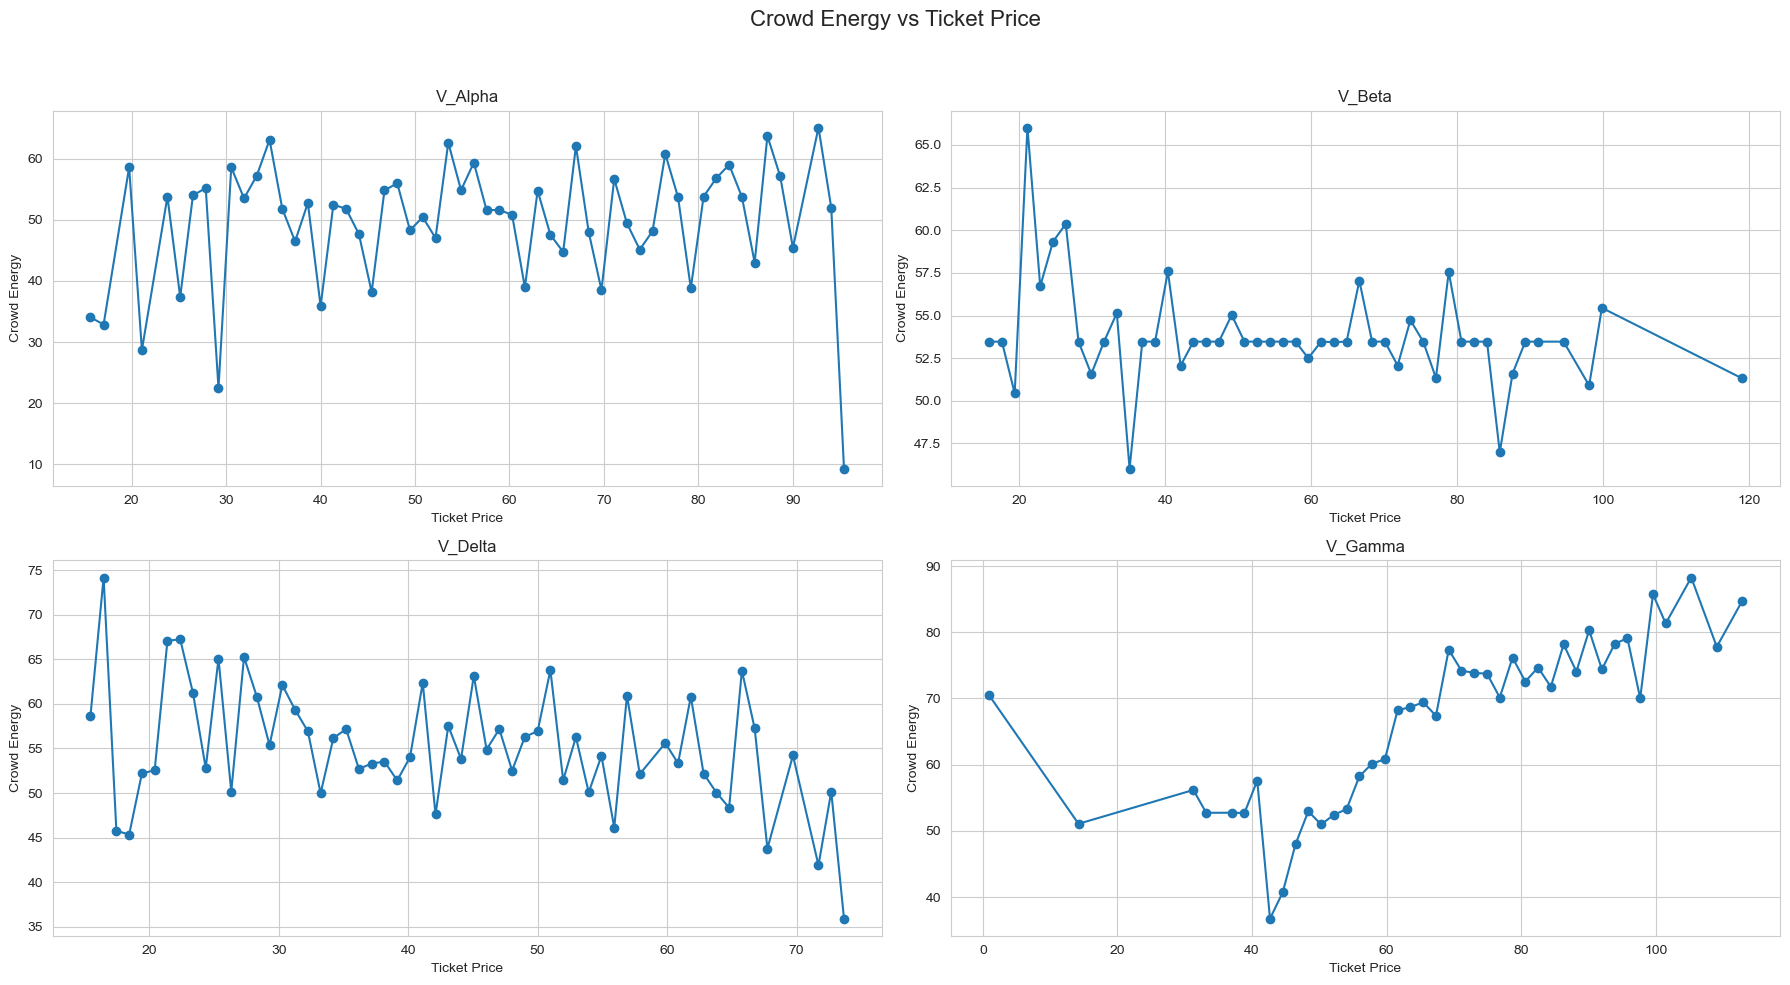

In [37]:
num_bins = 60 

venues = train["Venue_ID"].unique()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, venue in zip(axes, venues):

    df_v = train[train["Venue_ID"] == venue]

    # Bin Ticket_Price
    ticket_bins = pd.cut(df_v["Ticket_Price"], bins=num_bins)

    # Median Crowd Energy per bin
    stats = (
        df_v
        .groupby(ticket_bins, observed=True)["Crowd_Energy"]
        .median()
        .reset_index()
    )

    # Bin midpoints
    stats["bin_mid"] = stats["Ticket_Price"].apply(lambda x: x.mid)

    ax.plot(
        stats["bin_mid"],
        stats["Crowd_Energy"],
        marker='o',
        linestyle='-'
    )

    ax.set_title(f"{venue}")
    ax.set_xlabel("Ticket Price")
    ax.set_ylabel("Crowd Energy")
    ax.grid(True)

plt.suptitle("Crowd Energy vs Ticket Price", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


OBSERVATION: 

For Venue V_Gamma as ticket prices reach approx 40 the crowd energy decreases on average but therafter increases on average till the max ticket price
Business Idea: May be there is a scope to increase the ticket prices.



Preventing Data Leakage (by dropping post show features)



In [38]:

X = train.drop(['Crowd_Energy', 'Gig_ID', 'Merch_Sales_Post_Show'], axis=1)
y = train['Crowd_Energy']
X_test = test.drop(['Gig_ID', 'Merch_Sales_Post_Show'], axis=1)


Doing hotencoding for Venue_ID, Moon_Phase, Weather, Band_Outfit

In [39]:

cat_cols = ["Venue_ID", "Weather", "Moon_Phase", "Band_Outfit"]

ct = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
], remainder='passthrough')

# Set output to pandas for better understanding
if hasattr(ct, "set_output"):
    ct.set_output(transform="pandas")

X = ct.fit_transform(X)

X_test = ct.transform(X_test)

# make names simple
X.columns = [c.split('__')[-1] for c in X.columns]
X_test.columns = [c.split('__')[-1] for c in X_test.columns]

Converting all true false to 1 and 0 respectively for further training purposes.

In [40]:
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

bool_cols = X_test.select_dtypes(include='bool').columns
X_test[bool_cols] = X_test[bool_cols].astype(int)


In [41]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1957 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Venue_ID_V_Alpha            1957 non-null   float64
 1   Venue_ID_V_Beta             1957 non-null   float64
 2   Venue_ID_V_Delta            1957 non-null   float64
 3   Venue_ID_V_Gamma            1957 non-null   float64
 4   Weather_Clear               1957 non-null   float64
 5   Weather_Cloudy              1957 non-null   float64
 6   Weather_Rainy               1957 non-null   float64
 7   Weather_Stormy              1957 non-null   float64
 8   Moon_Phase_First Quarter    1957 non-null   float64
 9   Moon_Phase_Full Moon        1957 non-null   float64
 10  Moon_Phase_Last Quarter     1957 non-null   float64
 11  Moon_Phase_New Moon         1957 non-null   float64
 12  Moon_Phase_Waning Crescent  1957 non-null   float64
 13  Moon_Phase_Waning Gibbous   1957 non-n

Checking our data preprocessing (the distribution of all four venues should remain approximately same)

In [42]:
venue_compare = pd.DataFrame({
    "Before": train_raw['Venue_ID'].value_counts(),
    "After": train['Venue_ID'].value_counts()
})

venue_compare["Before_%"] = venue_compare["Before"] / venue_compare["Before"].sum() * 100
venue_compare["After_%"]  = venue_compare["After"]  / venue_compare["After"].sum()  * 100

print(venue_compare)


          Before  After  Before_%    After_%
Venue_ID                                    
V_Delta      542    542     27.10  27.695452
V_Alpha      489    489     24.45  24.987225
V_Gamma      485    485     24.25  24.782831
V_Beta       484    441     24.20  22.534492


From above table we can see that our data preprocessing was unbaised.

Let us see the overall dataframe just in case any anamolies are left in it.

In [43]:
train.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
Day_of_Week,3.006643,2.024001,0.00,6.0
Volume_Level,5.466530,3.007919,1.00,11.0
Ticket_Price,52.183702,20.332796,0.00,120.0
Crowd_Size,536.851559,163.868577,100.00,1200.0
Opener_Rating,3.010731,1.409647,1.00,5.0
Merch_Sales_Post_Show,841.227389,266.226914,38.00,1529.0
Crowd_Energy,56.420835,16.595047,4.32,100.0
Time,19.116505,3.216413,6.00,23.0
Month,5.838528,1.925899,3.00,9.0


In [44]:
X_test.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
Venue_ID_V_Alpha,0.234000,0.423796,0.0,1.0
Venue_ID_V_Beta,0.292000,0.455138,0.0,1.0
Venue_ID_V_Delta,0.246000,0.431110,0.0,1.0
Venue_ID_V_Gamma,0.228000,0.419963,0.0,1.0
Weather_Clear,0.228000,0.419963,0.0,1.0
Weather_Cloudy,0.264000,0.441241,0.0,1.0
Weather_Rainy,0.238000,0.426286,0.0,1.0
Weather_Stormy,0.270000,0.444404,0.0,1.0
Moon_Phase_First Quarter,0.162000,0.368820,0.0,1.0
Moon_Phase_Full Moon,0.092000,0.289315,0.0,1.0


In [45]:
assert X.shape[1] == X_test.shape[1]


From above code we ensure that our X is properly mapped to X_test.

Checking if there are any null values left in our dataframes X and X_test.

In [46]:
X.isna().sum()

Venue_ID_V_Alpha              0
Venue_ID_V_Beta               0
Venue_ID_V_Delta              0
Venue_ID_V_Gamma              0
Weather_Clear                 0
Weather_Cloudy                0
Weather_Rainy                 0
Weather_Stormy                0
Moon_Phase_First Quarter      0
Moon_Phase_Full Moon          0
Moon_Phase_Last Quarter       0
Moon_Phase_New Moon           0
Moon_Phase_Waning Crescent    0
Moon_Phase_Waning Gibbous     0
Moon_Phase_Waxing Crescent    0
Moon_Phase_Waxing Gibbous     0
Band_Outfit_Denim             0
Band_Outfit_Leather           0
Band_Outfit_Spandex           0
Day_of_Week                   0
Volume_Level                  0
Ticket_Price                  0
Crowd_Size                    0
Opener_Rating                 0
Time                          0
Month                         0
dtype: int64

In [47]:
X_test.isna().sum()

Venue_ID_V_Alpha              0
Venue_ID_V_Beta               0
Venue_ID_V_Delta              0
Venue_ID_V_Gamma              0
Weather_Clear                 0
Weather_Cloudy                0
Weather_Rainy                 0
Weather_Stormy                0
Moon_Phase_First Quarter      0
Moon_Phase_Full Moon          0
Moon_Phase_Last Quarter       0
Moon_Phase_New Moon           0
Moon_Phase_Waning Crescent    0
Moon_Phase_Waning Gibbous     0
Moon_Phase_Waxing Crescent    0
Moon_Phase_Waxing Gibbous     0
Band_Outfit_Denim             0
Band_Outfit_Leather           0
Band_Outfit_Spandex           0
Day_of_Week                   0
Volume_Level                  0
Ticket_Price                  0
Crowd_Size                    0
Opener_Rating                 0
Time                          0
Month                         0
dtype: int64



Model Choice: RANDOMM FOREST REGRESSOR

Handles non-linear relationships better.

Lower variance than Single Decision Tree.

More efficient to noise and outliers.

Minimaml assumptions about data distribution.

(also tried GRADIENT BOOSTING METHOD but it didn't give any improvements in CV RSME (it gave around 12.8).

(also tried random search instead of grid but that also was not beneficial).



PIPELINE

In [48]:

pipe = Pipeline([
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])


HYPERPARAMETER TUNING

In [49]:
param_grid = {
    "model__n_estimators": [300, 600, 1000],  # increase model stability
    "model__max_depth": [None, 15, 25],       # Control tree complexity
    "model__min_samples_leaf": [1, 3, 7],     # Prevent overfitting
    "model__min_samples_split": [2, 5, 10],   # take care of extreme predictions
    "model__max_features": ["sqrt", 0.7]      # improve generalization
}


CROSS VALIDATION

In [50]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,               # K-fold cross validation
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)


TRAIN

In [51]:
grid.fit(X, y)

best_model = grid.best_estimator_


print("Best CV RMSE:", -grid.best_score_)


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best CV RMSE: 12.689268351972123


In [52]:
from sklearn.metrics import mean_squared_error
venue_median = train.groupby("Venue_ID")["Crowd_Energy"].median()
venue_preds = train["Venue_ID"].map(venue_median)
mse = mean_squared_error(y, venue_preds)
baseline_venue = np.sqrt(mse)

print("Venue baseline RMSE:", baseline_venue)


Venue baseline RMSE: 14.938254943475146


In [53]:
naive_rmse = np.sqrt(mean_squared_error(y, np.repeat(y.mean(), len(y))))
print("Naive mean baseline RMSE:", naive_rmse)


Naive mean baseline RMSE: 16.590806802017177


In [54]:
from sklearn.metrics import mean_squared_error

# Predictions on training data
train_preds = best_model.predict(X)

train_rmse = np.sqrt(mean_squared_error(y, train_preds))
cv_rmse = -grid.best_score_

print("Train RMSE:", train_rmse)
print("CV RMSE:", cv_rmse)


Train RMSE: 9.816956668382801
CV RMSE: 12.689268351972123


FEATURE IMPORTANCE

In [55]:

importances = best_model.named_steps["model"].feature_importances_

feat_imp = (
    pd.Series(importances, index=X.columns)
    .sort_values(ascending=False)
)

feat_imp.head(15)


Venue_ID_V_Gamma       0.237769
Volume_Level           0.165109
Ticket_Price           0.142194
Opener_Rating          0.082976
Crowd_Size             0.079586
Time                   0.063623
Day_of_Week            0.047075
Venue_ID_V_Alpha       0.042252
Month                  0.031825
Venue_ID_V_Beta        0.028334
Venue_ID_V_Delta       0.015771
Band_Outfit_Denim      0.010502
Weather_Stormy         0.009608
Band_Outfit_Leather    0.008186
Weather_Cloudy         0.005883
dtype: float64

RESIDUAL PLOT: just plotting it to see whether our model worked reasonably, the plot should be more or less uniformly scattered around the central line which can be seen clearly in the below graph.

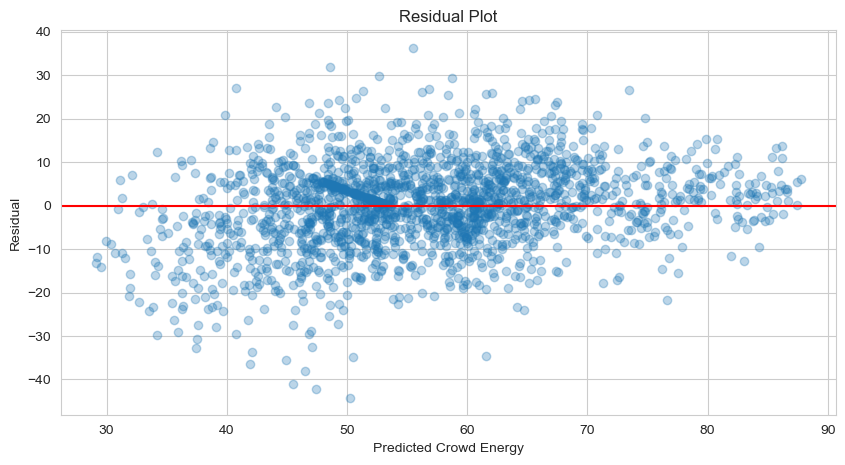

In [56]:
residuals = y - train_preds

plt.figure(figsize=(10,5))
plt.scatter(train_preds, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Predicted Crowd Energy")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = best_model
model.fit(X_tr, y_tr)

val_preds = model.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))

print("Validation RMSE:", val_rmse)


Validation RMSE: 12.137758275602499


In [58]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Predictions on training data
train_preds = best_model.predict(X)
train_rmse = np.sqrt(mean_squared_error(y, train_preds))  # manually sqrt
train_r2 = r2_score(y, train_preds)

# Cross-validation scores
cv_rmse_scores = np.sqrt(-cross_val_score(
    best_model, X, y, cv=5, scoring='neg_mean_squared_error'  # use neg_mse
))
cv_r2_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print(f"Train RMSE: {train_rmse:.3f}, Train R²: {train_r2:.3f}")
print(f"CV RMSE (5-fold): {cv_rmse_scores.mean():.3f} ± {cv_rmse_scores.std():.3f}")
print(f"CV R² (5-fold): {cv_r2_scores.mean():.3f} ± {cv_r2_scores.std():.3f}")


Train RMSE: 10.426, Train R²: 0.605
CV RMSE (5-fold): 12.689 ± 0.422
CV R² (5-fold): 0.413 ± 0.023


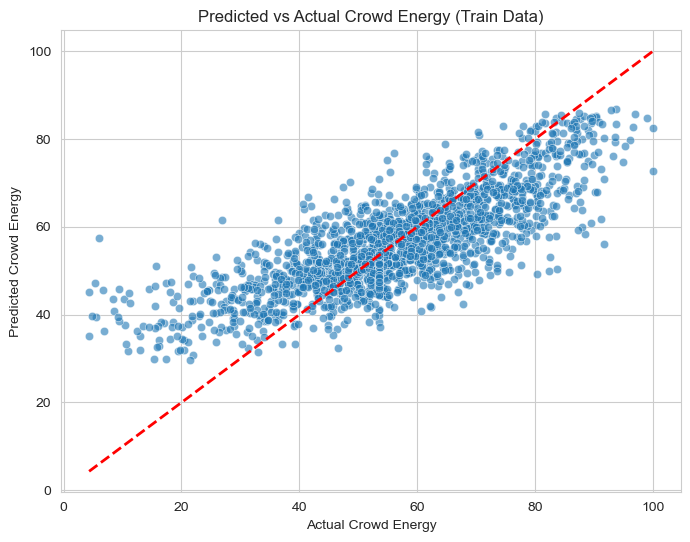

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions on training data
train_preds = best_model.predict(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=y, y=train_preds, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)  # perfect prediction line
plt.xlabel("Actual Crowd Energy")
plt.ylabel("Predicted Crowd Energy")
plt.title("Predicted vs Actual Crowd Energy (Train Data)")
plt.grid(True)
plt.show()



SUBMISSION FILE


In [60]:
test_preds = best_model.predict(X_test)

predictions = pd.DataFrame({
    "Gig_ID": test["Gig_ID"],
    "Crowd_Energy": test_preds
})

predictions["Crowd_Energy"] = predictions["Crowd_Energy"].clip(0, 100)

predictions.to_csv("predictions.csv", index=False)


In [61]:
predictions.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
Crowd_Energy,56.047073,10.598405,33.244213,85.541601


.

.

.



BONUS: REVENUE OPTIMIZATION FOR VENUE V_GAMMA (The Snob Pit)

                            

LOGICAL RESULT we should expect from our below calculations at the Venue V_Gamma.

We know from EDA that crowd energy has very weak correlation with ticket price i.e. they are not affected by the high prices of tickets.

And also on average there is higher crowd energy at V_Gamma for higher ticket prices.

And also crowd size and crowd energy have weak correlation.

So, logically we should expect optimal price of ticket to be quite high and the associated crowd size will also be at the higher side.

Assumptions:

We assumed relation between crowd energy and crowd size to be linear (as the plot of crowd energy v/s crowd size in EDA was quite complex).

So, we just created a linear model:
Attendence (say x)= min(800, C* crowd_energy), where C is mean crowd size/mean crowd energy.

So, Profit will be x*p-(5000+8*x) where p is the ticket price.

Since we had to calculate the energy without inputting the crowd size (attendence) we just used median to nullify the effect otherwise it would have been a circular logic.

In [62]:
c = train["Crowd_Size"].mean() / train["Crowd_Energy"].mean()
print("C:", c)

scenario = (
    X[X["Venue_ID_V_Gamma"] == 1]
    .median()
    .to_frame()
    .T
)
import numpy as np

prices = np.linspace(10, 120, 100)

profits = []
attendances = []
energies = []

for p in prices:
    scenario["Ticket_Price"] = p
    
    # 🔹 Predict crowd energy using our model
    predicted_energy = best_model.predict(scenario)[0]
    
    # 🔹 Convert energy → attendance
    attendance = min(800, c * predicted_energy)
    
    # 🔹 Profit calculation
    profit = attendance * p - (5000 + 8 * attendance)
    
    energies.append(predicted_energy)
    attendances.append(attendance)
    profits.append(profit)

profits = np.array(profits)
best_idx = np.argmax(profits)

optimal_price = prices[best_idx]
max_profit = profits[best_idx]
optimal_attendance = attendances[best_idx]
optimal_energy = energies[best_idx]

print(f"Optimal Ticket Price: ₹{optimal_price:.2f}")
print(f"Max Profit: ₹{max_profit:,.0f}")
print(f"Expected Attendance: {optimal_attendance:.0f}")
print(f"Predicted Crowd Energy: {optimal_energy:.1f}")




C: 9.515129545809092
Optimal Ticket Price: ₹120.00
Max Profit: ₹75,768
Expected Attendance: 721
Predicted Crowd Energy: 75.8


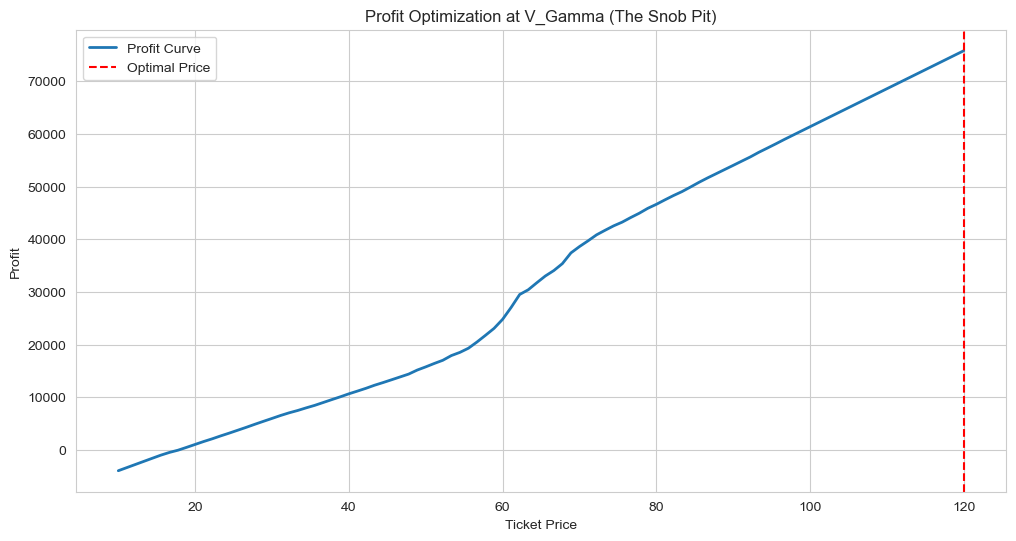

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(prices, profits, linewidth=2, label="Profit Curve")
plt.axvline(optimal_price, color="red", linestyle="--", label="Optimal Price")

plt.xlabel("Ticket Price")
plt.ylabel("Profit")
plt.title("Profit Optimization at V_Gamma (The Snob Pit)")
plt.legend()
plt.grid(True)
plt.show()


NOW LET USE PREDICT OPTIMAL TICKET PRICE DIRECTLY USING TRAINING DATASET NOT OUR MODEL

In [64]:
vg = train[
    (train["Venue_ID"] == "V_Gamma") &
    (train["Crowd_Size"] <= 800) &
    (train["Ticket_Price"] >= 0) &
    (train["Ticket_Price"] <= 120)
].copy()


In [65]:
vg["Profit"] = (
    vg["Crowd_Size"] * vg["Ticket_Price"]
    - (5000 + 8 * vg["Crowd_Size"])
)


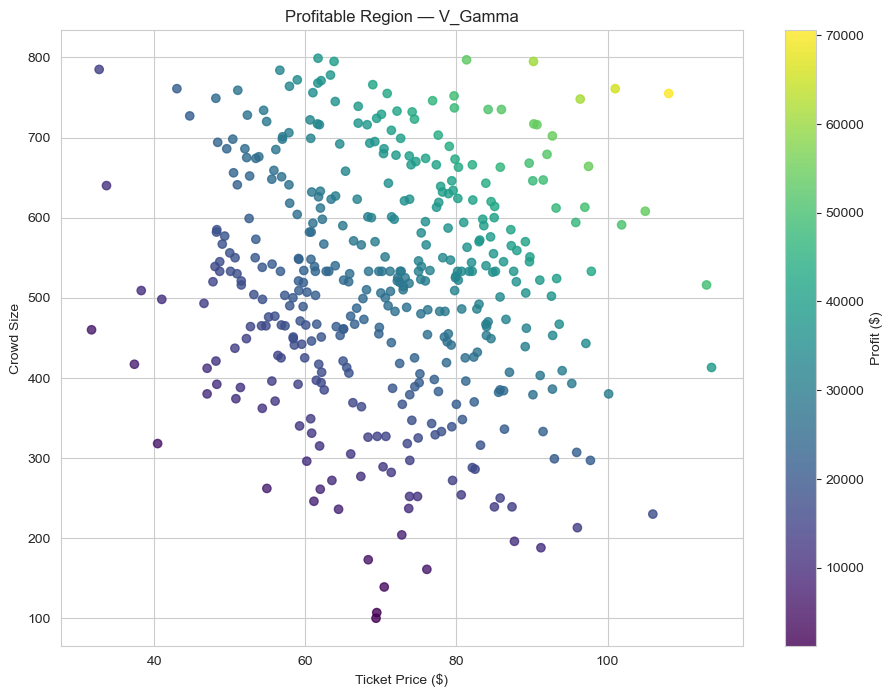

In [66]:
profitable = vg[vg["Profit"] > 0]

plt.figure(figsize=(11, 8))
plt.scatter(
    profitable["Ticket_Price"],
    profitable["Crowd_Size"],
    c=profitable["Profit"],
    cmap="viridis",
    alpha=0.8
)

plt.colorbar(label="Profit ($)")
plt.xlabel("Ticket Price ($)")
plt.ylabel("Crowd Size")
plt.title("Profitable Region — V_Gamma")
plt.show()


The above graph also agrees with our mathematical model which we created for optimal ticket pricing.